# Generative Models

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain what a generative model is and distinguish it from a discriminative model
- Fit a Gaussian mixture model (GMM) using scikit-learn and generate new synthetic data samples
- Apply the Bayesian Information Criterion (BIC) to select the optimal number of GMM components
- Combine PCA with a GMM to build a generative model for high-dimensional data
- Estimate a probability density using kernel density estimation (KDE) and compare KDE to histograms
- Select the optimal KDE bandwidth via cross-validation using held-out log-likelihood
- Build a full generative model for a high-dimensional process dataset by combining standardization, PCA, and GMM
- Implement a non-naive Bayesian classifier using per-class KDE densities and interpret its accuracy
- Apply density-based anomaly detection by scoring samples under a fitted generative model
:::

## Generative Model Overview

Generative models describe the probability distribution of the underlying data. Unlike
supervised models, which learn a mapping from inputs to outputs, a generative model learns
**how the data is distributed** in feature space. This is an **unsupervised** approach because
no output labels are required.

Formally, a generative model estimates the probability of observing a data point $\mathbf{x}$:

$$P(\mathbf{x} \mid \text{features})$$

Once this distribution is known, it can be used to:

- **Sample** new data points that statistically resemble the original dataset — useful for
  augmenting sparse or imbalanced datasets
- **Score** new points to detect anomalies (low-probability regions indicate unusual conditions)
- **Combine with Bayes' theorem** to build probabilistic classifiers without training a
  discriminative model directly

You may already be familiar with the word *generative* from large language models such as
GPT. The connection is direct: a language model estimates
$P(\text{next token} \mid \text{all preceding tokens})$ and samples from it one token at a
time to produce text. The feature space is a vocabulary of tens of thousands of tokens, and
a document lives in an astronomically high-dimensional space — yet the core operation is
identical to what we do in this chapter: learn a probability distribution from data, then
sample from it. The methods here (GMMs, KDE) are tailored to continuous, moderate-dimensional
data such as process sensor readings, but the conceptual bridge to language and image
generation is short.

In chemical engineering specifically, generative models appear in process monitoring
(detecting off-spec operating conditions), materials design (proposing candidate molecular
structures), and data augmentation when new experiments are expensive.

:::{exercise}
:label: ex-eda-gen-conditional

Generative models are built on **conditional probability**, $P(A \mid B)$ — "the probability
of $A$ given that $B$ is true" — combined through Bayes' theorem. A classic illustration is
testing for a rare disease.

Suppose a disease affects **1 in 1,000** people. A test correctly flags **99%** of people who
have the disease (true-positive rate) but also wrongly flags **5%** of healthy people
(false-positive rate). A randomly chosen person tests **positive**.

(a) Before any arithmetic, write down your gut estimate: how likely is it that this person
actually has the disease?

(b) Now compute it with Bayes' theorem,

$$P(\text{disease}\mid +) = \frac{P(+\mid \text{disease})\,P(\text{disease})}
{P(+\mid \text{disease})\,P(\text{disease}) + P(+\mid \text{healthy})\,P(\text{healthy})}$$

Plug in the numbers ($P(\text{disease}) = 0.001$, $P(+\mid\text{disease}) = 0.99$,
$P(+\mid\text{healthy}) = 0.05$) and report $P(\text{disease}\mid +)$.

(c) The result (about 2%) is far below most people's intuition in part (a). Explain why the
**base rate** — the 1-in-1,000 prior — dominates the answer, and connect this to generative
classification: why must a classifier weight each class-conditional density $P(\mathbf{x}\mid y)$
by its prior $P(y)$ rather than comparing the densities alone?
:::

## Normal Distribution

The simplest generative model in one dimension is the Gaussian (normal) distribution. We
access it through `scipy.stats.norm`, which provides methods for the probability density
function (PDF), the cumulative distribution function (CDF), and drawing random samples.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233', '#808080'])

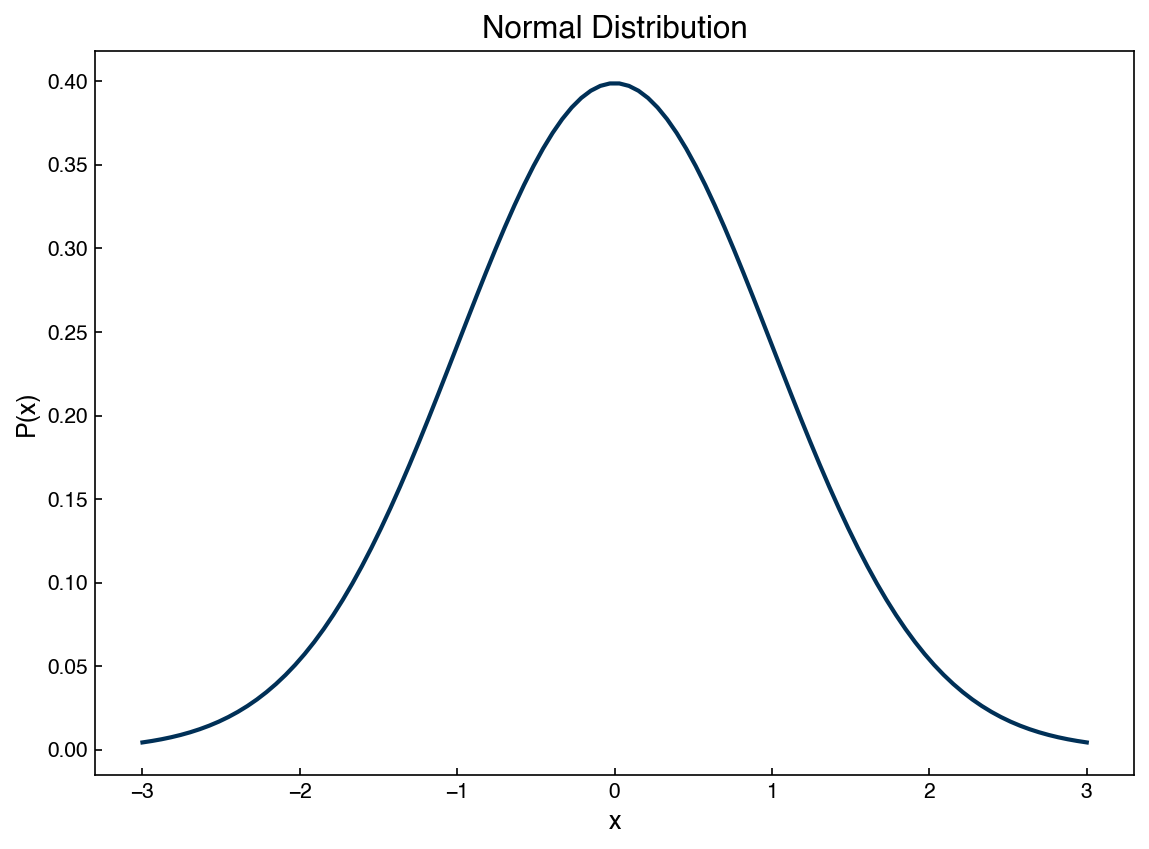

In [2]:
from scipy.stats import norm

mu, variance = 0, 1
sigma = np.sqrt(variance)
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100)

fig, ax = plt.subplots()
ax.plot(x, norm.pdf(x, mu, sigma))
ax.set_title('Normal Distribution')
ax.set_xlabel('x')
ax.set_ylabel('P(x)');

We can now use `norm.rvs` to draw random samples and verify that the histogram of those
samples matches the PDF:

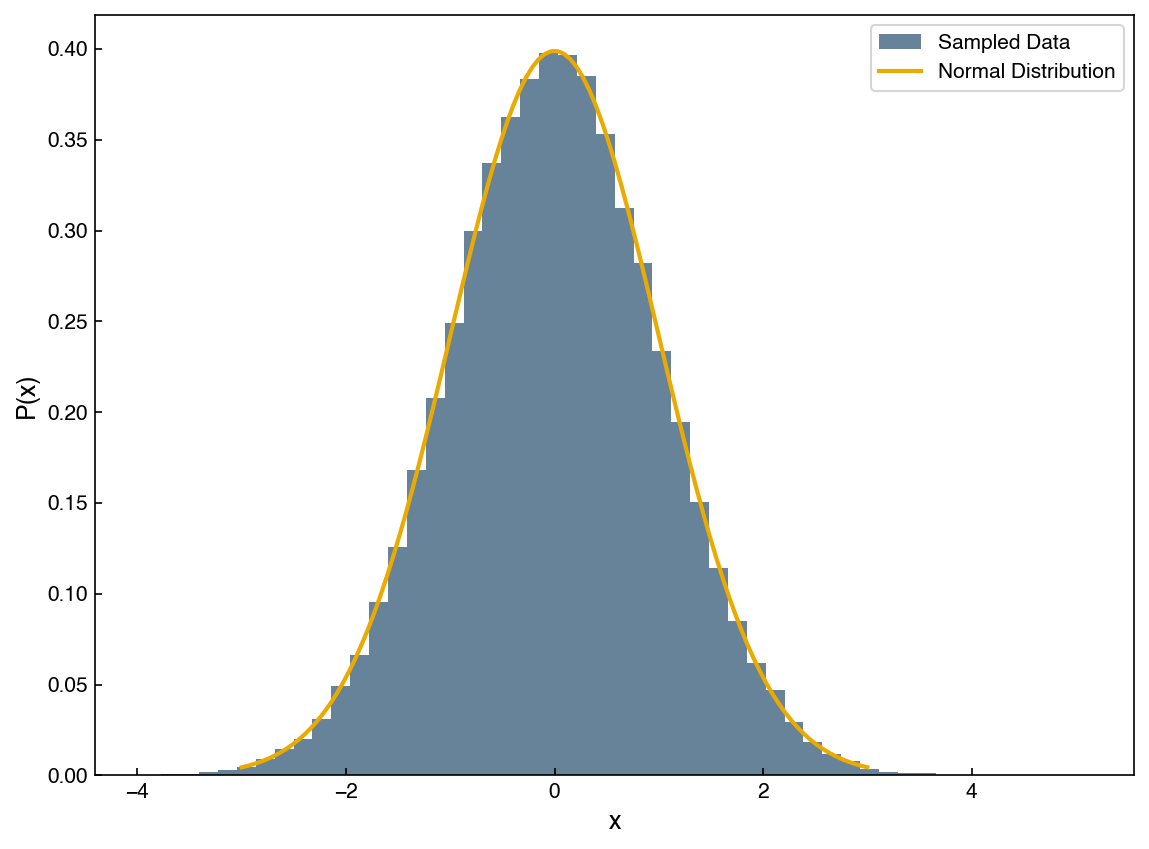

In [3]:
X_new = norm.rvs(mu, sigma, size=100_000)

fig, ax = plt.subplots()
ax.hist(X_new, density=True, bins=50, alpha=0.6, label='Sampled Data')
ax.plot(x, norm.pdf(x, mu, sigma), linewidth=2, label='Normal Distribution')
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('P(x)');

This is the core idea of generative modeling: learn the parameters of a probability
distribution from data, then sample from it to create new synthetic points. For the simple
Gaussian case we need only two parameters, $\mu$ and $\sigma$.

Let's apply this to one feature of the Dow Chemical distillation column dataset:

In [4]:
def is_real_and_finite(x):
    return np.isreal(x) and np.isfinite(x)

df = pd.read_excel('data/impurity_dataset-training.xlsx')

all_data = df[df.columns[1:]].values  # drop date column
numeric_map = df[df.columns[1:]].apply(lambda col: col.map(is_real_and_finite))
real_rows = numeric_map.all(axis=1).values

X_dow = np.array(all_data[real_rows, :-5], dtype='float')
y_dow = np.array(all_data[real_rows, -3], dtype='float').reshape(-1, 1)
print(X_dow.shape, y_dow.shape)

(10297, 40) (10297, 1)


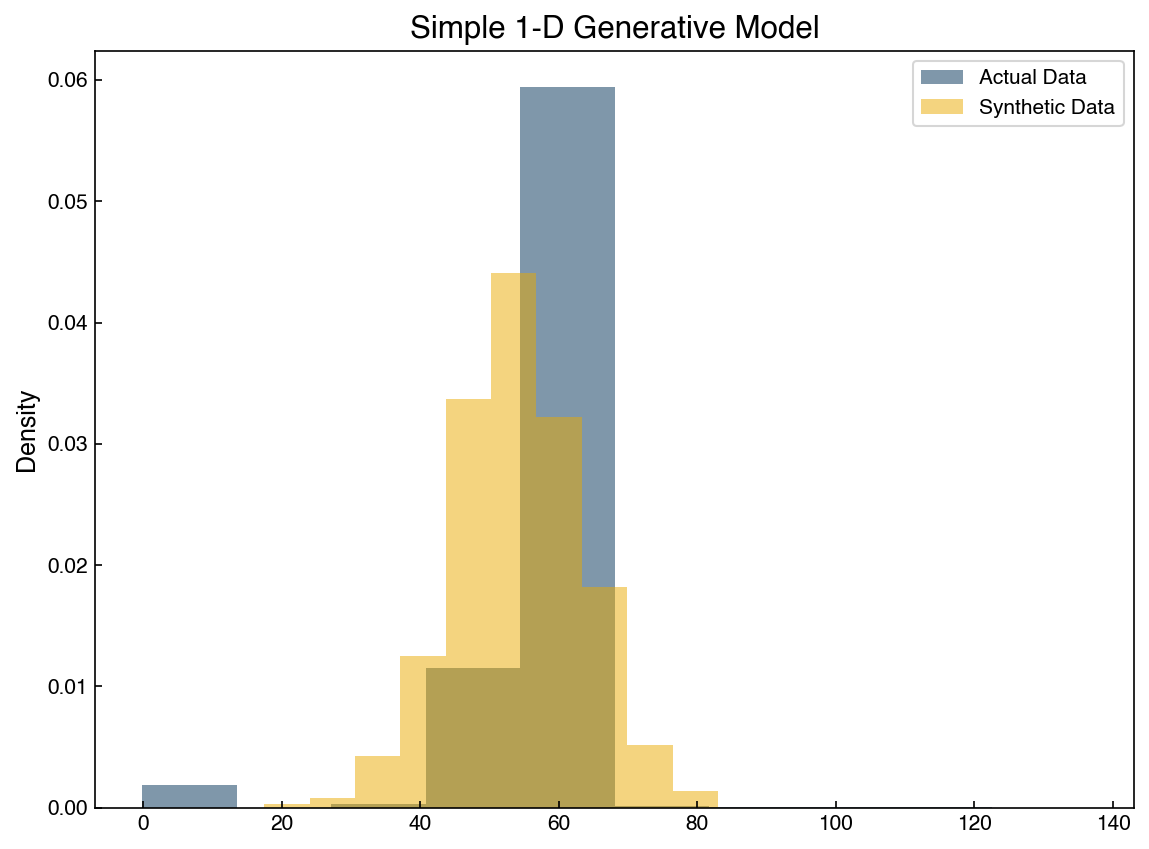

In [5]:
feature = 6
x_1d = X_dow[:, feature]

mu_fit = x_1d.mean()
std_fit = x_1d.std()
x_synthetic = norm.rvs(mu_fit, std_fit, size=1000)

fig, ax = plt.subplots()
ax.hist(x_1d, density=True, alpha=0.5, label='Actual Data')
ax.hist(x_synthetic, density=True, alpha=0.5, label='Synthetic Data')
ax.set_title('Simple 1-D Generative Model')
ax.set_ylabel('Density')
ax.legend();

The distributions are broadly similar but do not match exactly — this feature is not perfectly
Gaussian. Furthermore, this captures only one of the 40 features, so a single fitted normal
distribution is a very limited generative model for the full dataset.

:::{exercise}
:label: ex-eda-norm-fit

Select a different feature from the Dow dataset (try column index 10 or 20). Fit a normal
distribution to that feature, generate 500 synthetic samples using `norm.rvs`, and overlay
the histogram of the synthetic samples on a histogram of the real data. Comment on whether
the Gaussian assumption appears reasonable for your chosen feature.
:::

## Gaussian Mixture Models

A single Gaussian cannot represent multi-modal or strongly non-Gaussian distributions.
Gaussian Mixture Models (GMMs) address this by representing the full distribution as a
**weighted sum of Gaussians**:

$$P(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where $\pi_k$ are mixing weights (summing to 1), $\boldsymbol{\mu}_k$ are component means, and
$\boldsymbol{\Sigma}_k$ are covariance matrices. The model is fit using the
**Expectation-Maximization (EM)** algorithm, which alternates between assigning points to
components (E-step) and updating component parameters to maximize the likelihood (M-step).

We met GMMs and the EM algorithm in [Clustering](Topic5.3-Clustering), where the goal was to
*assign* each point to a group. Here the emphasis shifts: we treat the fitted GMM as a full
**probability distribution** $P(\mathbf{x})$ that we can sample from to create new data and
evaluate to score how typical a point is. The mechanics of fitting are identical; what changes
is what we do with the result.

Let's visualize two features of the Dow dataset simultaneously:

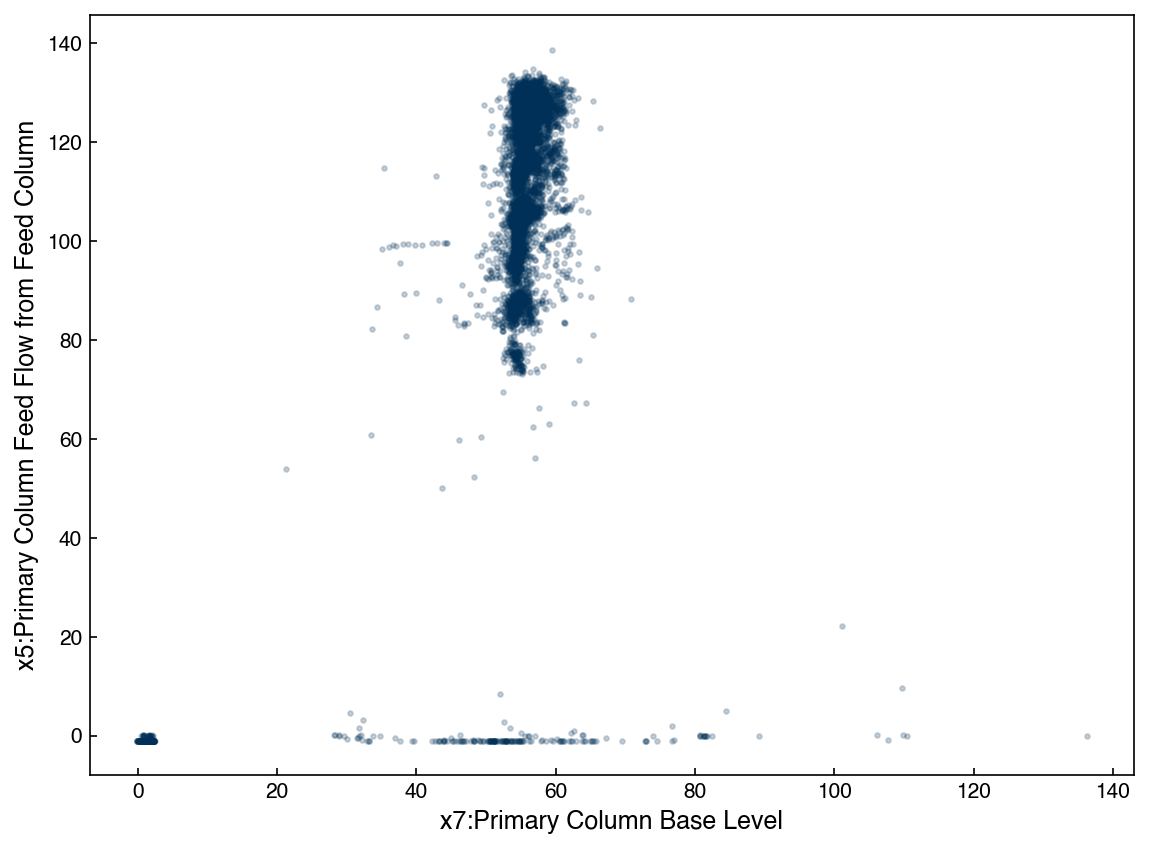

In [6]:
feature_A, feature_B = 6, 4
X_2d = X_dow[:, [feature_A, feature_B]]

fig, ax = plt.subplots()
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.2, s=5)
ax.set_xlabel(df.columns[7])
ax.set_ylabel(df.columns[5]);

The joint distribution is clearly non-Gaussian. We fit a GMM with 2 components:

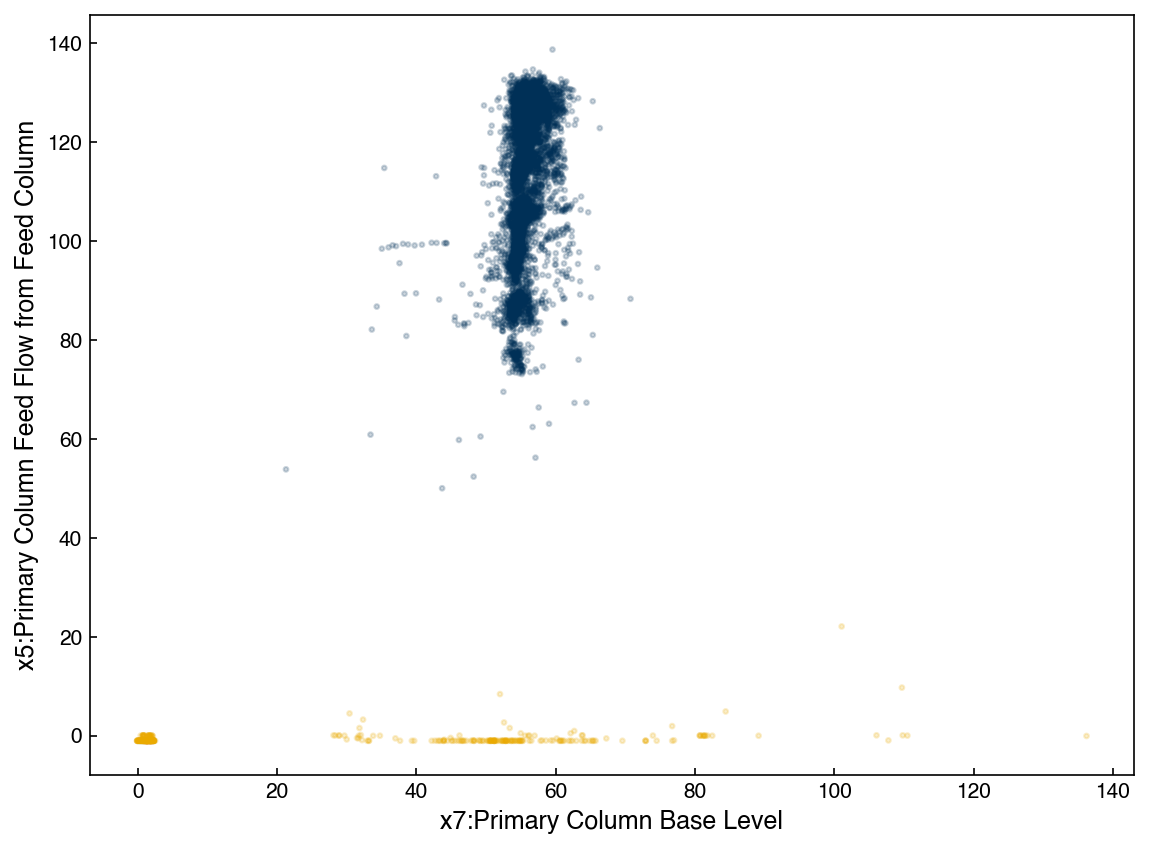

In [7]:
from sklearn.mixture import GaussianMixture

gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
gmm2.fit(X_2d)
labels_2 = gmm2.predict(X_2d)

fig, ax = plt.subplots()
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.2, s=5, c=clrs[labels_2])
ax.set_xlabel(df.columns[7])
ax.set_ylabel(df.columns[5]);

To visualize the fitted Gaussians we draw confidence ellipses. The helper functions below
(adapted from the
[Python Data Science Handbook](https://github.com/jakevdp/PythonDataScienceHandbook) are
provided for visualization purposes — you do not need to understand their internals.

In [8]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, color='gray', **kwargs):
    """Draw nested 1-, 2-, 3-sigma ellipses filled with `color`. The translucent layers
    stack, so each component is darkest at its center and fades toward its edge."""
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height, angle=angle,
                             facecolor=color, edgecolor='none', alpha=0.15, **kwargs))

def plot_gmm(gmm, X, label=True, ax=None):
    """Scatter X colored by GMM assignment, with translucent per-class component ellipses."""
    if ax is None:
        fig, ax = plt.subplots()
    labels = gmm.fit(X).predict(X)
    c = clrs[labels] if label else None
    ax.scatter(X[:, 0], X[:, 1], c=c, s=14, zorder=1, alpha=0.12)
    ax.axis('equal')
    for k, (pos, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
        # shade each component in its own class color; layered transparency darkens the center
        draw_ellipse(pos, covar, ax=ax, color=clrs[k % len(clrs)], zorder=2)
    return ax

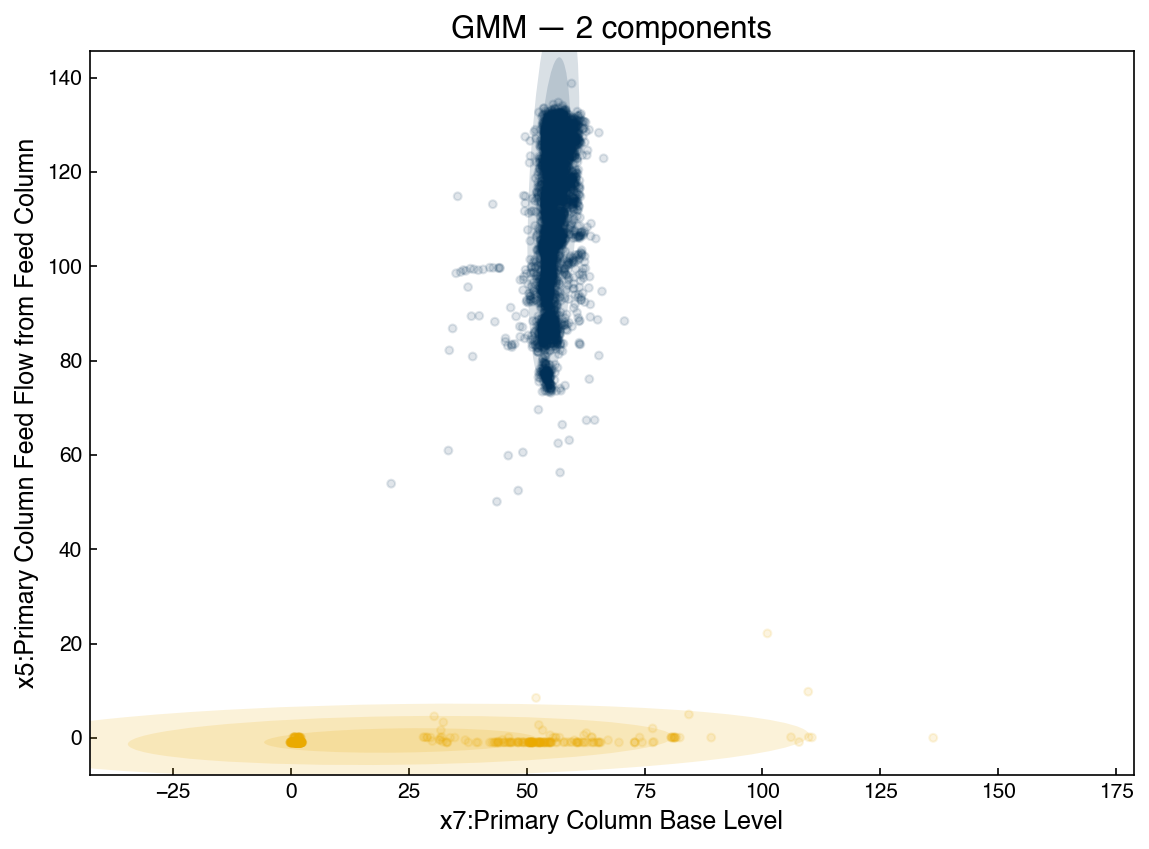

In [9]:
ax = plot_gmm(gmm2, X_2d)
ax.set_xlabel(df.columns[7])
ax.set_ylabel(df.columns[5])
ax.set_title('GMM — 2 components');

Two Gaussians do not describe the data well. As we increase the number of components the
fit improves:

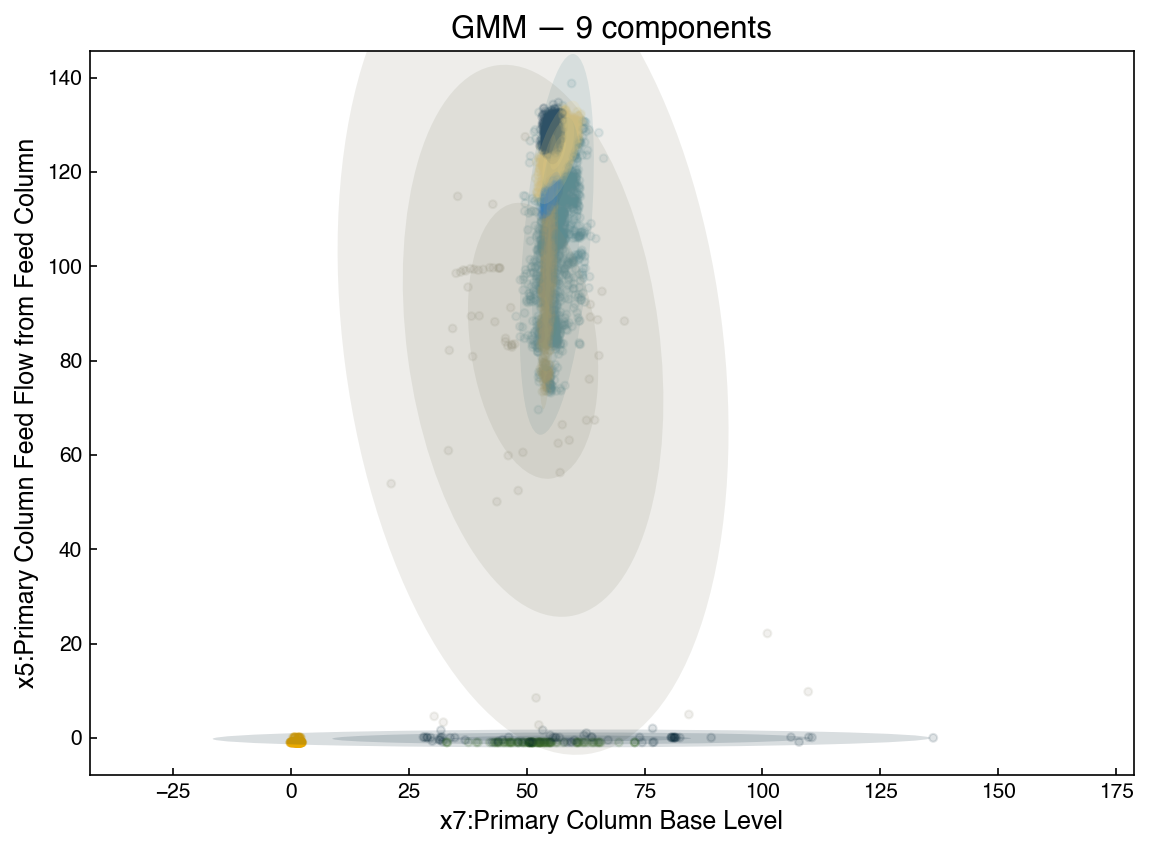

In [10]:
gmm9 = GaussianMixture(n_components=9, covariance_type='full', random_state=0)
ax = plot_gmm(gmm9, X_2d)
ax.set_xlabel(df.columns[7])
ax.set_ylabel(df.columns[5])
ax.set_title('GMM — 9 components');

Generating synthetic data is built into `GaussianMixture` via the `sample` method, which
returns a tuple `(X_samples, component_labels)`:

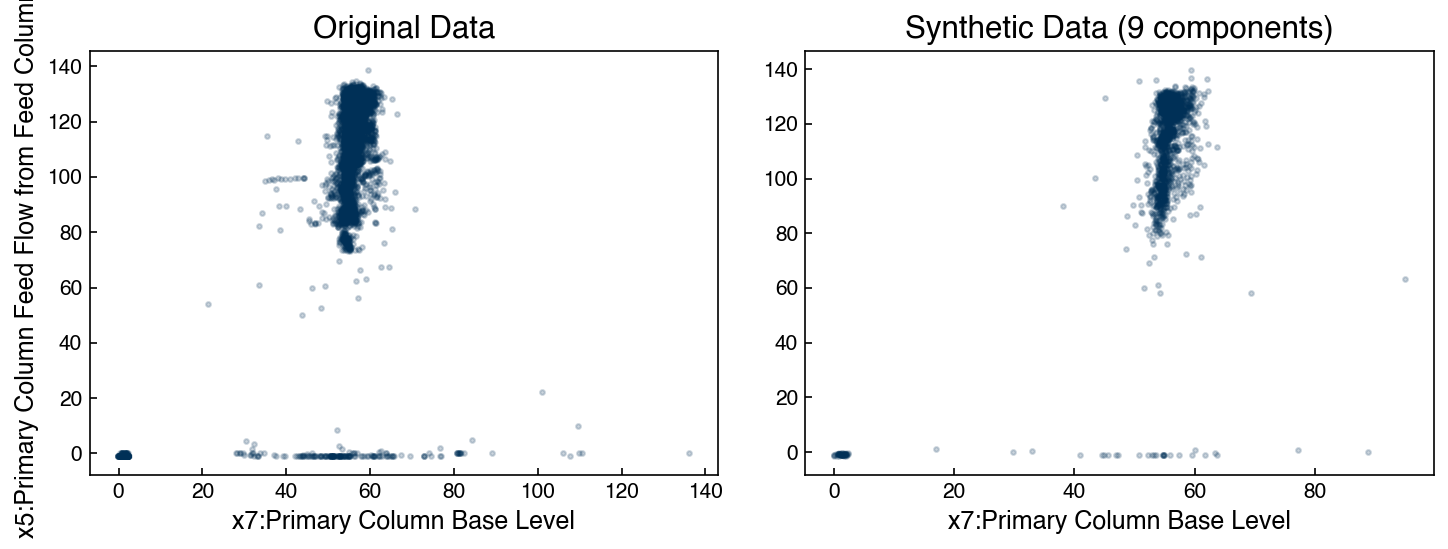

In [11]:
X_new, _ = gmm9.sample(2000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.2, s=5)
axes[0].set_title('Original Data')
axes[1].scatter(X_new[:, 0], X_new[:, 1], alpha=0.2, s=5)
axes[1].set_title('Synthetic Data (9 components)')
for ax in axes:
    ax.set_xlabel(df.columns[7])
axes[0].set_ylabel(df.columns[5]);

The main structural features are captured. However, we need a principled way to choose the
number of components.

### Bayesian Information Criterion

The Bayesian Information Criterion (BIC), introduced for model selection in
[Complexity and Optimization](../2-regression/Topic2.3-Complexity_Optimization), applies
here too. It provides a principled tradeoff between goodness-of-fit and model complexity:

$$\text{BIC} = \ln(n) \cdot k - 2 \ln(\hat{L})$$

where $n$ is the number of data points, $k$ is the number of free parameters, and $\hat{L}$
is the maximized likelihood. The **lower** the BIC, the better. Adding more Gaussian
components improves the likelihood term but increases $k$, so the BIC eventually rises again.
The optimal model minimizes the BIC.

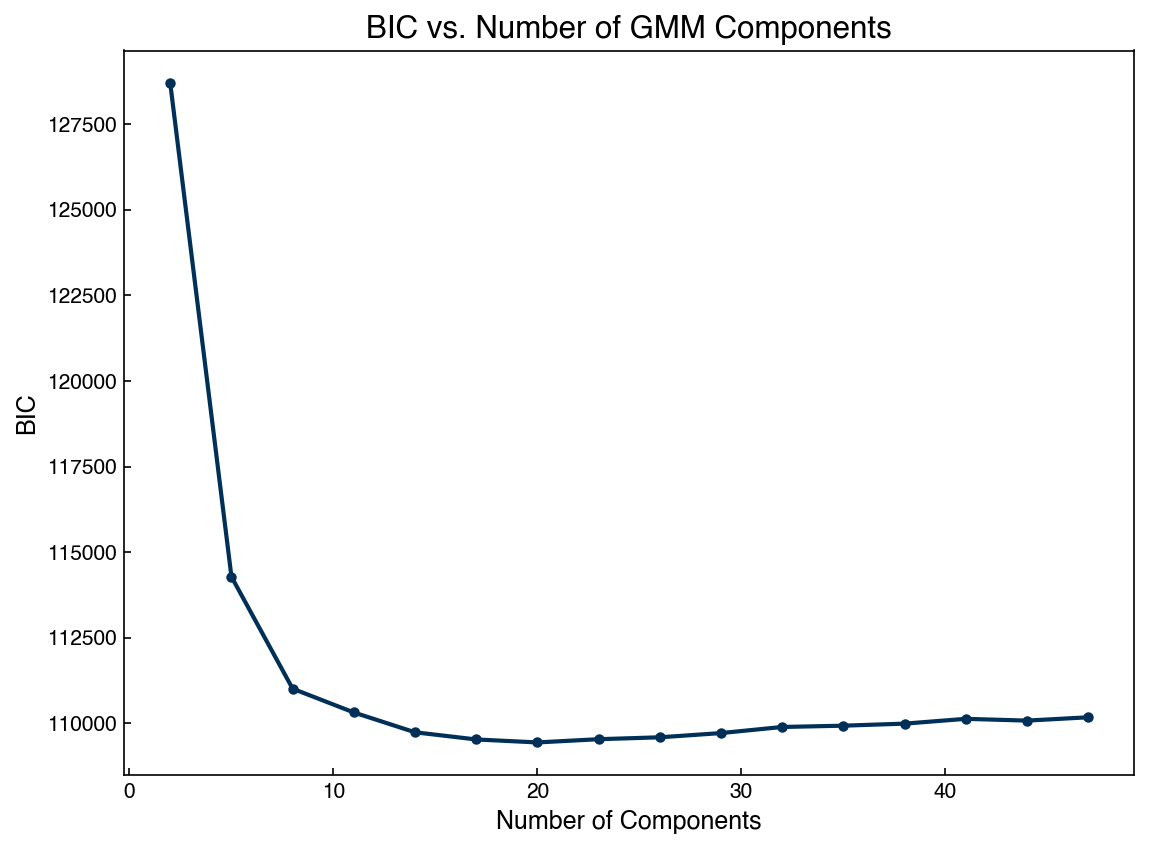

In [12]:
n_components = np.arange(2, 50, 3)
bics = []
for n in n_components:
    bic = GaussianMixture(n, covariance_type='full',
                          random_state=0).fit(X_2d).bic(X_2d)
    bics.append(bic)

fig, ax = plt.subplots()
ax.plot(n_components, bics, marker='o', markersize=4)
ax.set_xlabel('Number of Components')
ax.set_ylabel('BIC')
ax.set_title('BIC vs. Number of GMM Components');

The BIC reaches a minimum around 20 components, indicating this is the best balance between
accuracy and complexity for this 2-D dataset.

:::{exercise}
:label: ex-eda-gmm-bic3d

Extend the 2-D GMM analysis to three features so that `X_3d = X_dow[:, [2, 4, 6]]`. To keep
the fits quick, subsample first (e.g. `X_3d = X_3d[::5]`, ~2,000 rows). Fit GMMs with 2 to 20
components using `covariance_type='full'` and plot the BIC curve. Does the optimal number of
components increase compared to the 2-D case? Explain why in one sentence.
:::

## Generative Models in High Dimensions

GMMs do not scale easily to high-dimensional data because the number of free parameters in a
full covariance matrix grows as $\mathcal{O}(N_d^2)$, where $N_d$ is the number of
dimensions. A practical strategy is to first reduce dimensionality with PCA and then fit a
GMM in the compressed space. Because PCA is invertible, samples drawn from the GMM can be
projected back to the original feature space using the inverse transform.

We demonstrate this on the MNIST digits dataset (1797 samples, 64 pixel features):

In [13]:
from sklearn.datasets import load_digits

digits = load_digits()
X_mnist = np.array(digits.data)
y_mnist = np.array(digits.target)
print(f"Data shape: {X_mnist.shape}")
print(f"Target shape: {y_mnist.shape}")

Data shape: (1797, 64)
Target shape: (1797,)


In [14]:
def show_image(digit_data, ax=None):
    """Display a single 8x8 digit image from a flat 64-element array."""
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(np.array(digit_data).reshape(8, 8), cmap='binary')
    ax.axis('off')

**Step 1 — fit a GMM directly in 64-D** to establish a baseline:

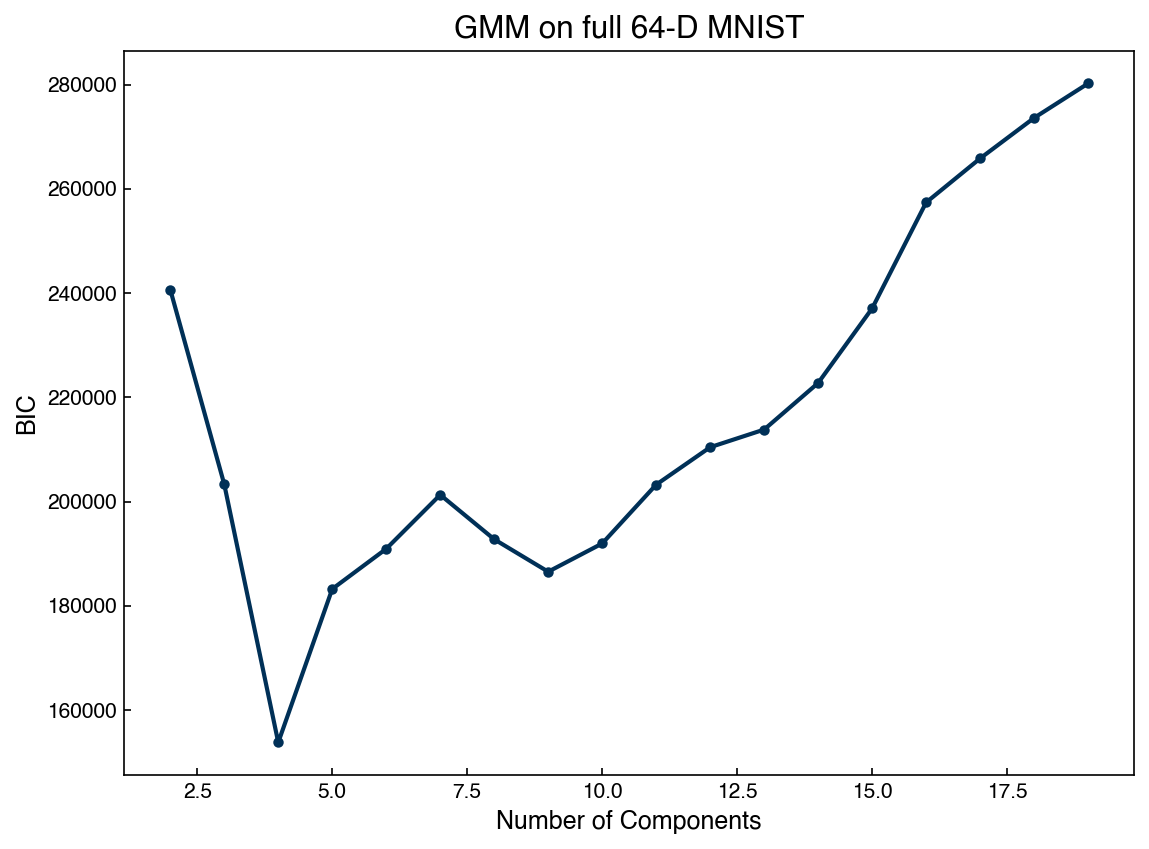

In [15]:
n_range = np.arange(2, 20)
bics_full, models_full = [], []
for n in n_range:
    g = GaussianMixture(n, covariance_type='full',
                        random_state=0).fit(X_mnist)
    bics_full.append(g.bic(X_mnist))
    models_full.append(g)

fig, ax = plt.subplots()
ax.plot(n_range, bics_full, marker='o', markersize=4)
ax.set_xlabel('Number of Components')
ax.set_ylabel('BIC')
ax.set_title('GMM on full 64-D MNIST');

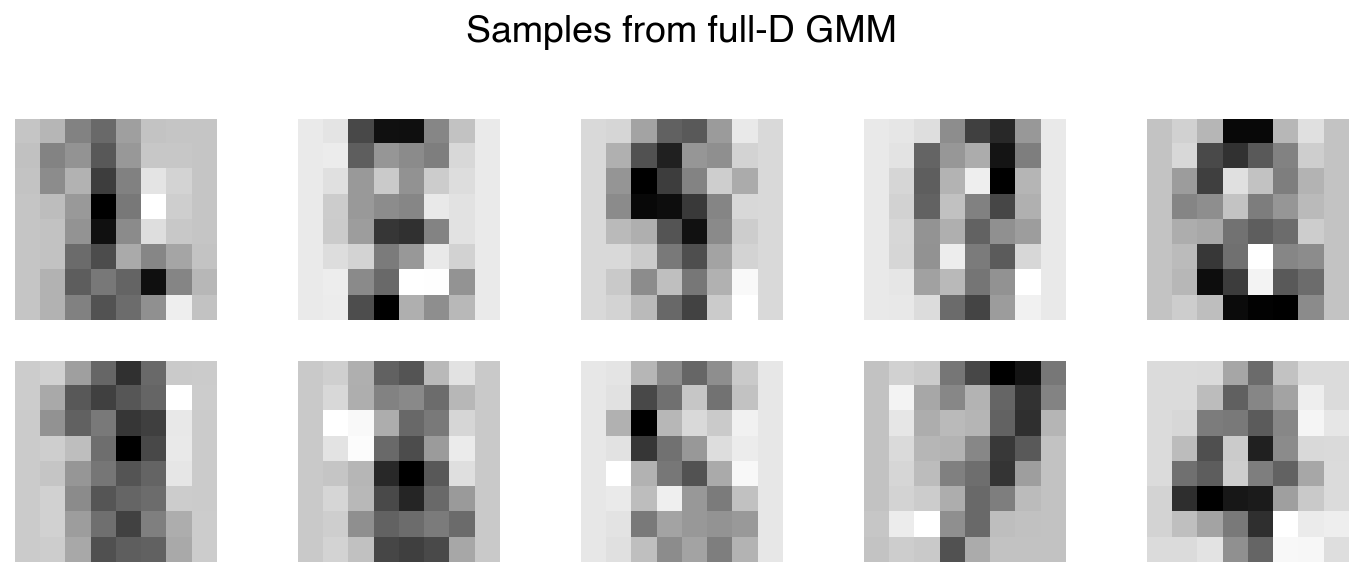

In [16]:
best_full = models_full[np.argmin(bics_full)]

# Draw all 10 samples in one call so each is different
X_samples, _ = best_full.sample(n_samples=10)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, sample in zip(axes.ravel(), X_samples):
    show_image(sample, ax=ax)
fig.suptitle('Samples from full-D GMM');

The generated images show some digit-like structure, but fitting a GMM in 64 dimensions is
computationally expensive and the results are limited.

**Step 2 — PCA + GMM** for a more efficient generative model:

In [17]:
from sklearn.decomposition import PCA

k = 30
pca = PCA(n_components=k, random_state=0)
X_k = pca.fit_transform(X_mnist)
print(f"Reduced shape: {X_k.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")

Reduced shape: (1797, 30)
Variance retained: 95.9%


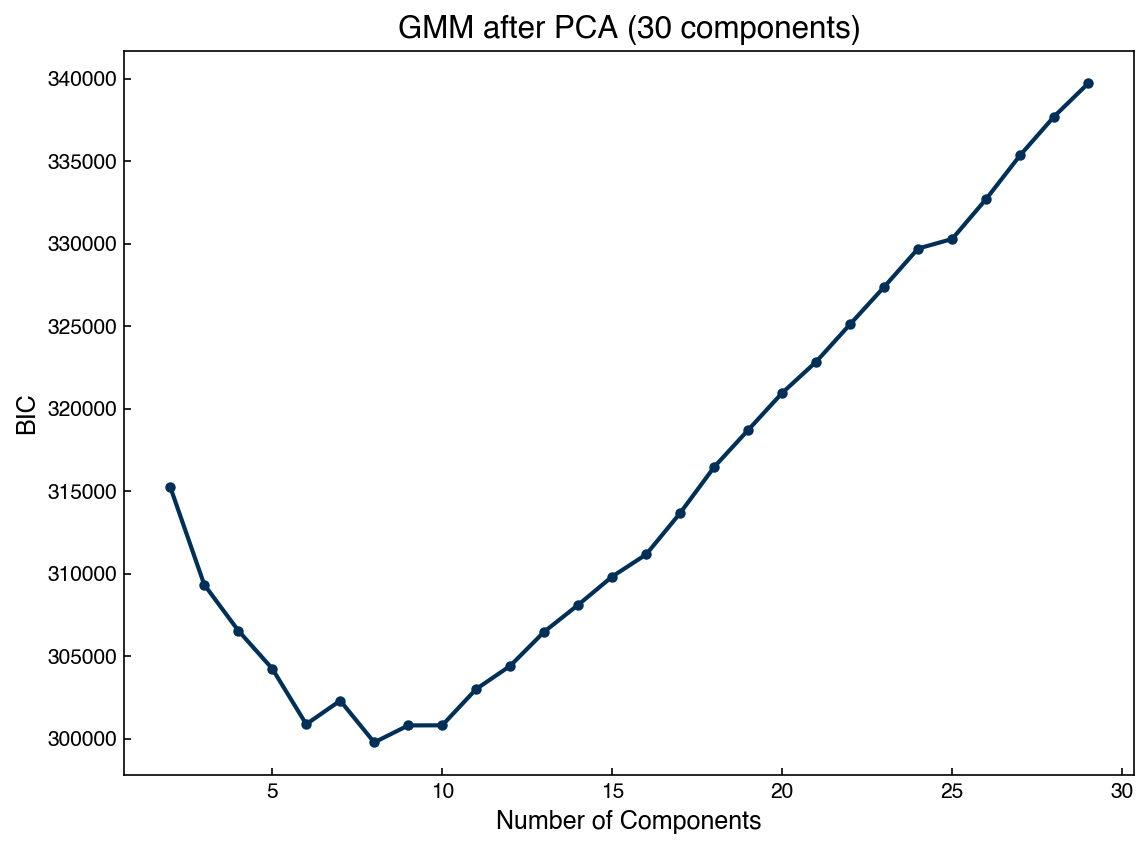

In [18]:
n_gmm_range = np.arange(2, 30)
bics_pca, models_pca = [], []
for n in n_gmm_range:
    g = GaussianMixture(n, covariance_type='full',
                        random_state=0).fit(X_k)
    bics_pca.append(g.bic(X_k))
    models_pca.append(g)

fig, ax = plt.subplots()
ax.plot(n_gmm_range, bics_pca, marker='o', markersize=4)
ax.set_xlabel('Number of Components')
ax.set_ylabel('BIC')
ax.set_title('GMM after PCA (30 components)');

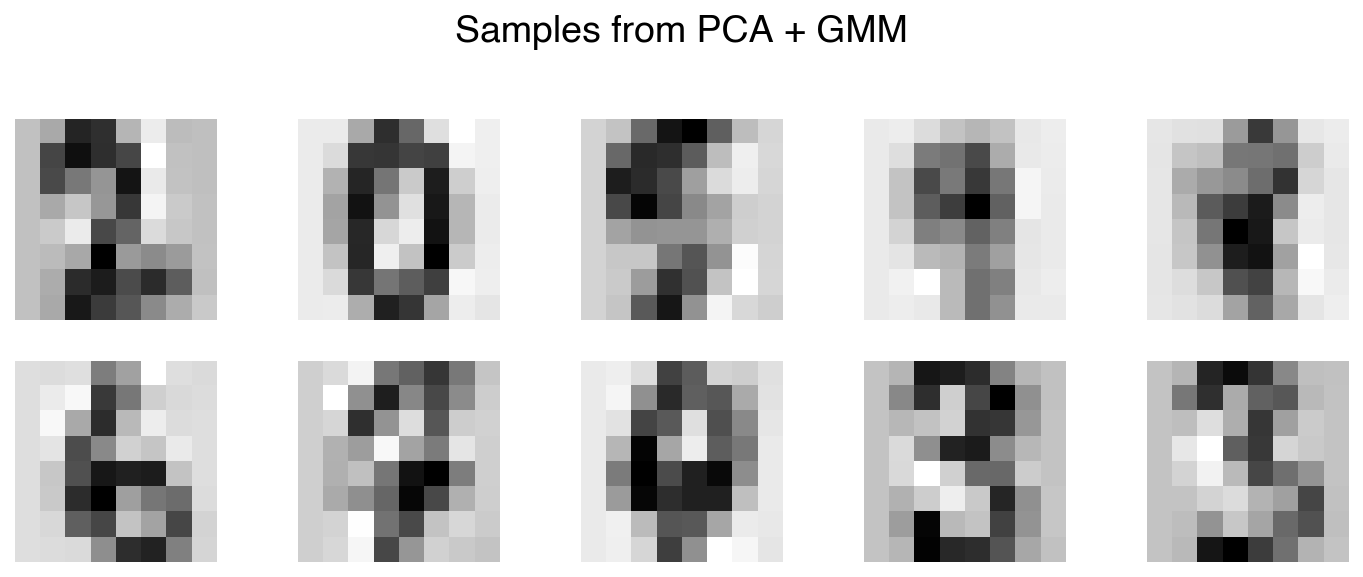

In [19]:
best_pca = models_pca[np.argmin(bics_pca)]

# Sample all 10 at once, then batch-invert the PCA transform
X_samples_low, _ = best_pca.sample(n_samples=10)
X_samples_high = pca.inverse_transform(X_samples_low)  # shape (10, 64)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, sample in zip(axes.ravel(), X_samples_high):
    show_image(sample, ax=ax)
fig.suptitle('Samples from PCA + GMM');

The PCA + GMM pipeline produces visually comparable or better results while working in a
30-D space instead of 64-D. With 30 PCA components we retain over 90% of the variance, so
very little information is lost in the projection.

### Demonstration: Generating New Examples of a Single Digit

We can restrict the GMM to data from one class to produce class-conditional samples. The
steps are: (1) select only class data, (2) compress with PCA to reduce parameter count,
(3) use BIC to select the number of components, (4) sample from the GMM and invert the PCA
transform.

Here we build a generator for the digit **6**:

In [20]:
X_6 = X_mnist[y_mnist == 6]
print(f"Digit-6 samples: {X_6.shape[0]}")

pca_6 = PCA(n_components=20, random_state=0)
X_6_k = pca_6.fit_transform(X_6)

n_range_6 = np.arange(2, 15)
bics_6, models_6 = [], []
for n in n_range_6:
    g = GaussianMixture(n, covariance_type='full',
                        random_state=0).fit(X_6_k)
    bics_6.append(g.bic(X_6_k))
    models_6.append(g)

best_idx = np.argmin(bics_6)
best_6 = models_6[best_idx]
print(f"Optimal components: {n_range_6[best_idx]}")

Digit-6 samples: 181
Optimal components: 14


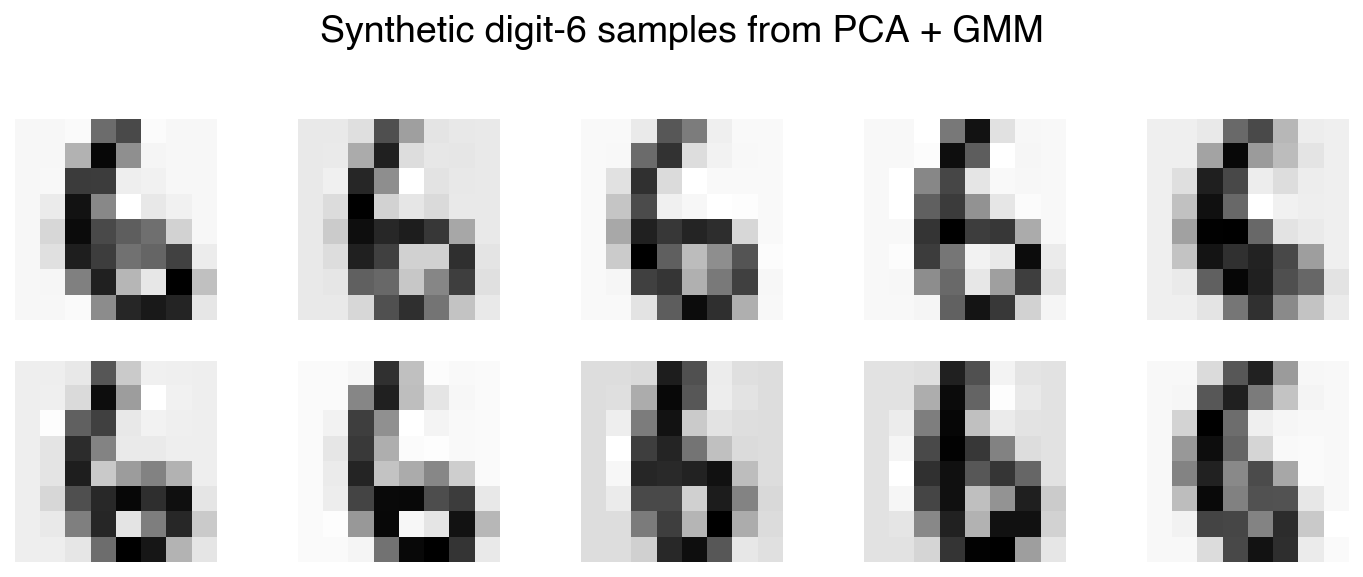

In [21]:
s_samples_low, _ = best_6.sample(n_samples=10)
s_samples_high = pca_6.inverse_transform(s_samples_low)  # shape (10, 64)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, sample in zip(axes.ravel(), s_samples_high):
    show_image(sample, ax=ax)
fig.suptitle('Synthetic digit-6 samples from PCA + GMM');

The generated images are recognizable as the digit 6. This class-conditional generative
pipeline is the foundation of modern data augmentation strategies used to address class
imbalance in deep learning — in our case with a simple GMM, and in state-of-the-art systems
with deep generative models such as Variational Autoencoders (VAEs).

:::{exercise}
:label: ex-eda-gmm-digit-other

Adapt the digit-6 demonstration above to generate synthetic samples for a digit of your
choice (0–9, excluding 6). Use `PCA(n_components=20)` and BIC to select the optimal number
of GMM components. Display a 2×5 grid of generated samples.
:::

## Kernel Density Estimation

Gaussian Mixture Models represent the data distribution with a fixed number of Gaussians
$K$. As $K$ grows the fit improves but generalization can degrade. Kernel Density Estimation
(KDE) takes this logic to its extreme: it places one Gaussian kernel **at every data point**,
giving a fully non-parametric density estimate:

$$\hat{f}(x) = \frac{1}{N h} \sum_{i=1}^{N} K\!\left(\frac{x - x_i}{h}\right)$$

where $h$ is the **bandwidth** (the width of each kernel) and $K(\cdot)$ is the kernel
function (typically Gaussian). KDE can represent arbitrarily complex distributions and makes
no assumption about the number of clusters.

### KDE vs. Histograms

Histograms require bin edges to be chosen in advance, and the resulting density estimate can
be sensitive to that choice. KDE provides a smooth alternative controlled only by the
bandwidth parameter:

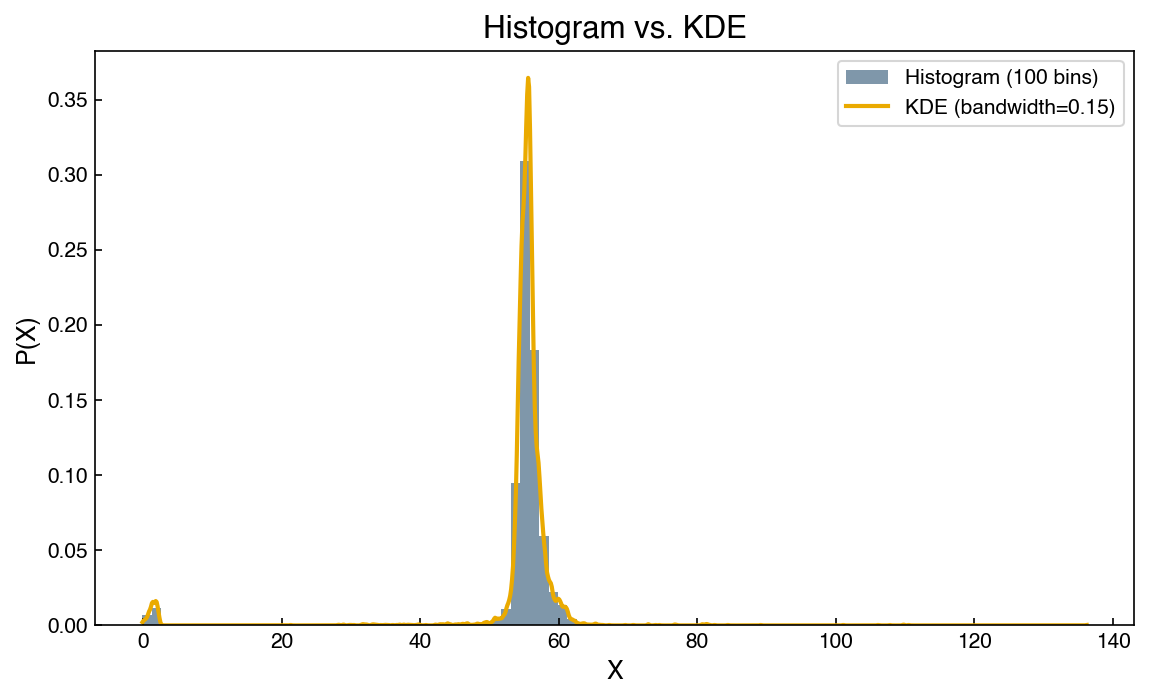

In [22]:
from sklearn.neighbors import KernelDensity

x_1d_col = X_dow[:, 6].reshape(-1, 1)

kde = KernelDensity(bandwidth=0.15, kernel='gaussian')
kde.fit(x_1d_col)

x_cont = np.linspace(x_1d_col.min(), x_1d_col.max(), 1000).reshape(-1, 1)
log_prob = kde.score_samples(x_cont)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x_1d_col, density=True, bins=100, alpha=0.5, label='Histogram (100 bins)')
ax.plot(x_cont, np.exp(log_prob), linewidth=2, label='KDE (bandwidth=0.15)')
ax.set_xlabel('X')
ax.set_ylabel('P(X)')
ax.set_title('Histogram vs. KDE')
ax.legend();

The KDE curve is smooth and does not depend on arbitrary bin boundaries. The bandwidth $h$
plays a role similar to bin width: too small and the estimate is noisy (overfitting each data
point), too large and features are washed out (underfitting). One practical advantage over the
histogram is that the KDE varies *continuously* with the bandwidth — nudging $h$ slightly
shifts the curve smoothly — whereas a histogram changes in discrete jumps as bins are added or
removed and can look qualitatively different from one bin count to the next.

Like a GMM, a fitted KDE model can generate new synthetic samples:

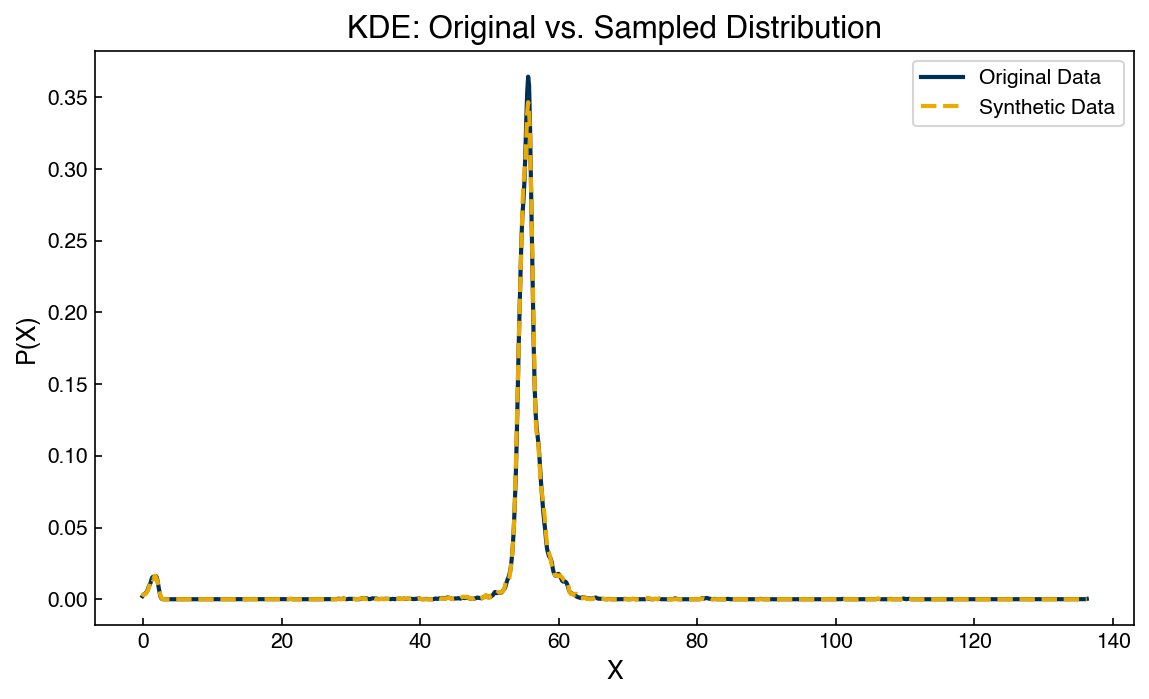

In [23]:
X_synthetic = kde.sample(10_000)

kde_synth = KernelDensity(bandwidth=0.15, kernel='gaussian').fit(X_synthetic)
log_prob_synth = kde_synth.score_samples(x_cont)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_cont, np.exp(log_prob), linewidth=2, label='Original Data')
ax.plot(x_cont, np.exp(log_prob_synth), linewidth=2, linestyle='--',
        label='Synthetic Data')
ax.set_xlabel('X')
ax.set_ylabel('P(X)')
ax.legend()
ax.set_title('KDE: Original vs. Sampled Distribution');

The sampled distribution closely matches the original, confirming that the KDE has captured
the data density accurately.

:::{exercise}
:label: ex-eda-kde-bandwidth

Fit KDE models to the same Dow feature using three different bandwidths: 0.01, 0.15, and
1.0. Plot the three KDE curves on the same axes alongside a histogram of the original data.
Describe qualitatively how the bandwidth controls the bias-variance tradeoff in density
estimation.
:::

### Bandwidth Selection via Cross-Validation

Rather than tuning the bandwidth by hand, we can treat it as a hyperparameter and select
it via cross-validation. `GridSearchCV` maximizes the mean held-out log-likelihood across
$k$ folds — a natural scoring criterion for density models.

Cross-validation works best here when the data has more than one distinct peak. If a
too-large bandwidth blurs two real peaks together, the resulting density assigns low
probability to the held-out points that fall near those peaks — and cross-validation
notices, scoring that bandwidth poorly. We illustrate with a synthetic two-peak dataset
before applying the procedure to real data:

In [24]:
from sklearn.model_selection import GridSearchCV

# Synthetic bimodal distribution — two populations with different spreads
rng = np.random.default_rng(42)
x_bimodal = np.concatenate([
    rng.normal(-2.0, 0.5, 500),
    rng.normal( 2.0, 0.8, 500),
]).reshape(-1, 1)

bandwidths = np.logspace(-1.5, 0.5, 40)  # 0.03 to 3.2
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                    {'bandwidth': bandwidths},
                    cv=5)
grid.fit(x_bimodal)

best_bw = grid.best_params_['bandwidth']
print(f"Optimal bandwidth: {best_bw:.4f}")

Optimal bandwidth: 0.1859


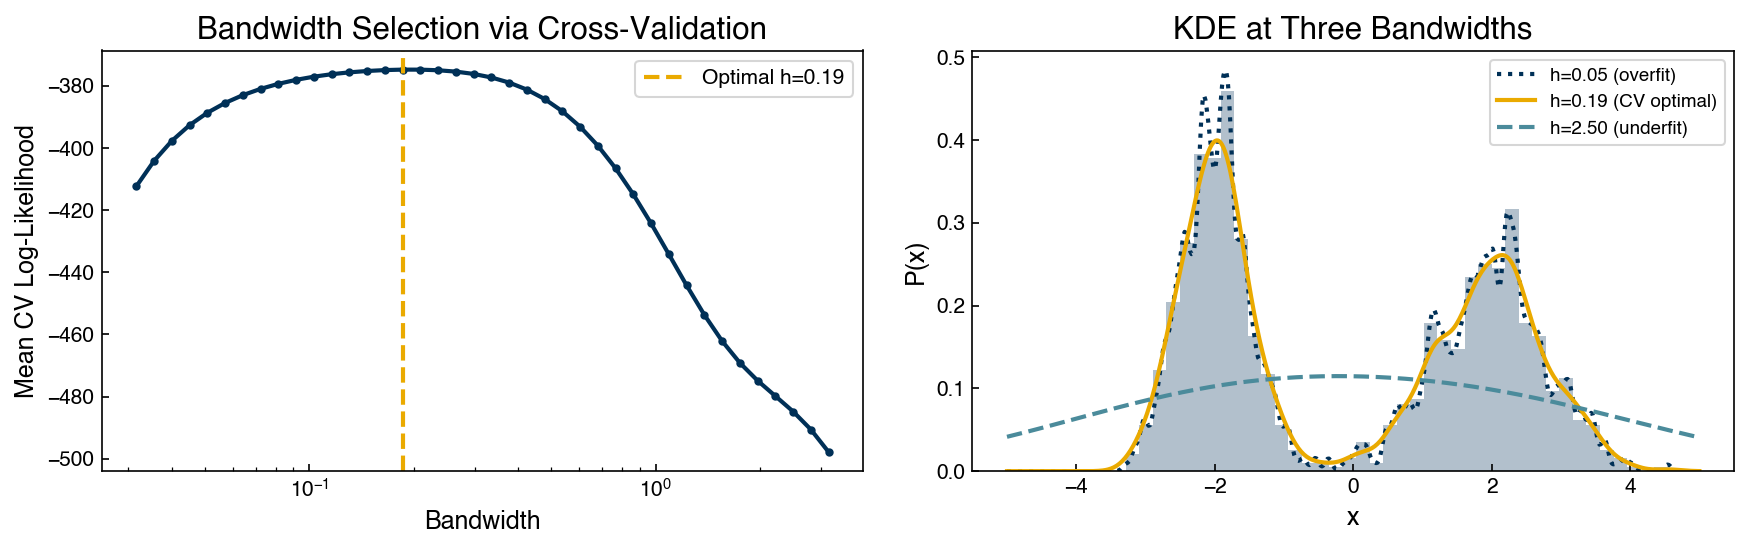

In [25]:
cv_scores = grid.cv_results_['mean_test_score']
x_grid = np.linspace(-5, 5, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: CV log-likelihood curve
axes[0].semilogx(bandwidths, cv_scores, marker='o', markersize=3)
axes[0].axvline(best_bw, color=clrs[1], linestyle='--',
                label=f'Optimal h={best_bw:.2f}')
axes[0].set_xlabel('Bandwidth')
axes[0].set_ylabel('Mean CV Log-Likelihood')
axes[0].set_title('Bandwidth Selection via Cross-Validation')
axes[0].legend()

# Right: KDE at three bandwidths to show each regime
for bw, ls, lbl in [(0.05,    ':',  'h=0.05 (overfit)'),
                     (best_bw, '-',  f'h={best_bw:.2f} (CV optimal)'),
                     (2.5,     '--', 'h=2.50 (underfit)')]:
    lp = KernelDensity(bandwidth=bw, kernel='gaussian').fit(x_bimodal).score_samples(x_grid)
    axes[1].plot(x_grid, np.exp(lp), linestyle=ls, linewidth=2, label=lbl)
axes[1].hist(x_bimodal, density=True, bins=40, alpha=0.3, color=clrs[0])
axes[1].set_xlabel('x')
axes[1].set_ylabel('P(x)')
axes[1].set_title('KDE at Three Bandwidths')
axes[1].legend(fontsize=9)

plt.tight_layout();

The CV curve has a clear peak at the optimal bandwidth. The right panel shows why: a
bandwidth of 0.05 spikes around individual data points (overfitting); the CV-optimal
bandwidth cleanly resolves both modes; a bandwidth of 2.5 merges the two populations into
a single broad hump (underfitting). The held-out log-likelihood falls sharply in both
extreme cases, giving the CV a reliable signal to optimize.

This procedure applies directly to real data, but a practical complication arises with
large datasets: with ~10,000 points the held-out log-likelihood becomes nearly flat because
a test point almost always lands close to a training point regardless of bandwidth.
**Subsampling** to ~1,000 points restores the CV's discriminating power while preserving
the shape of the distribution. The bandwidth found on the subsample is then used to fit a
KDE on the full dataset.

In [26]:
# Subsample for CV, fit final model on all data
rng_sub = np.random.default_rng(0)
idx_sub = rng_sub.choice(len(x_1d_col), size=1000, replace=False)
x_dow_sub = x_1d_col[idx_sub]

# Fine grid (60 log-spaced points, 0.1–10) with 10-fold CV
bandwidths_dow = np.logspace(-1, 1, 60)
grid_dow = GridSearchCV(KernelDensity(kernel='gaussian'),
                        {'bandwidth': bandwidths_dow},
                        cv=10)
grid_dow.fit(x_dow_sub)
best_bw_dow = grid_dow.best_params_['bandwidth']
print(f"Dow feature 6 optimal bandwidth: {best_bw_dow:.4f}")

Dow feature 6 optimal bandwidth: 0.6021


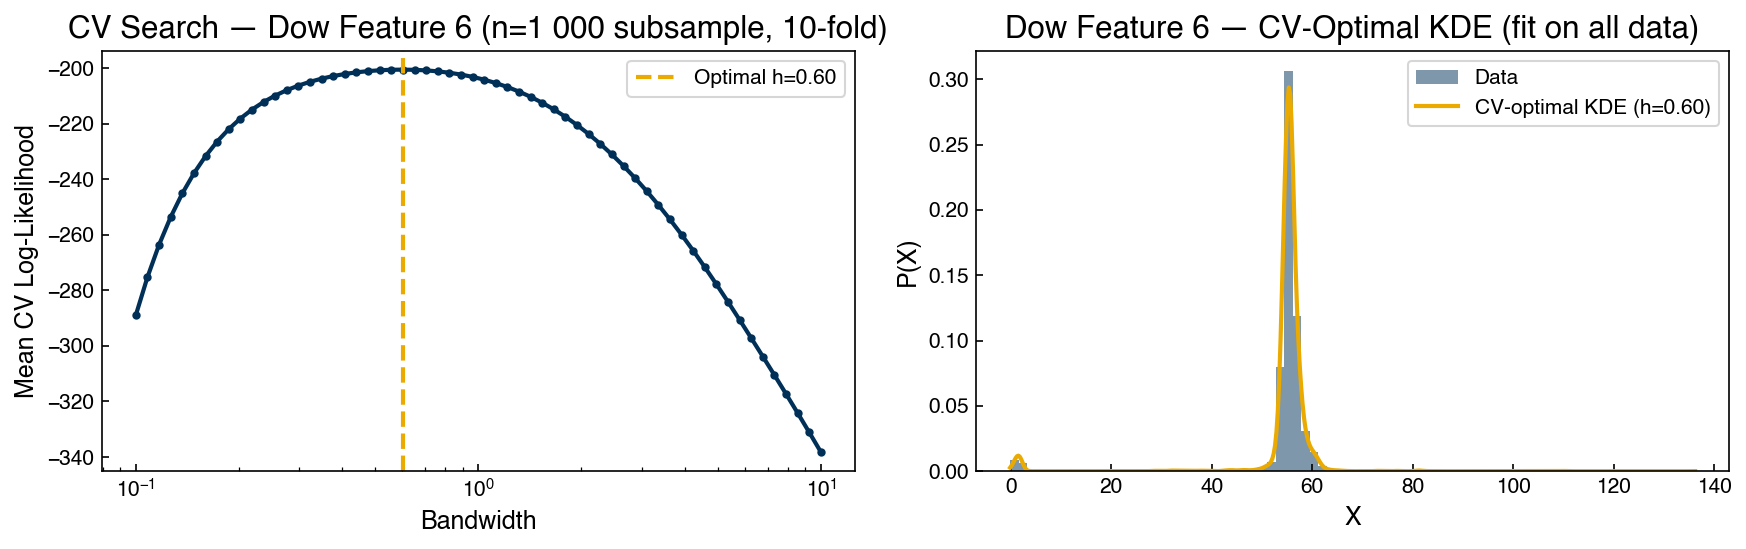

In [27]:
cv_scores_dow = grid_dow.cv_results_['mean_test_score']
x_cont_dow = np.linspace(x_1d_col.min(), x_1d_col.max(), 500).reshape(-1, 1)

# Refit on full dataset with the CV-selected bandwidth
kde_dow_opt = KernelDensity(bandwidth=best_bw_dow, kernel='gaussian').fit(x_1d_col)
lp_dow = kde_dow_opt.score_samples(x_cont_dow)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(bandwidths_dow, cv_scores_dow, marker='o', markersize=3)
axes[0].axvline(best_bw_dow, color=clrs[1], linestyle='--',
                label=f'Optimal h={best_bw_dow:.2f}')
axes[0].set_xlabel('Bandwidth')
axes[0].set_ylabel('Mean CV Log-Likelihood')
axes[0].set_title('CV Search — Dow Feature 6 (n=1 000 subsample, 10-fold)')
axes[0].legend()

axes[1].hist(x_1d_col, density=True, bins=80, alpha=0.5, label='Data')
axes[1].plot(x_cont_dow, np.exp(lp_dow), linewidth=2,
             label=f'CV-optimal KDE (h={best_bw_dow:.2f})')
axes[1].set_xlabel('X')
axes[1].set_ylabel('P(X)')
axes[1].set_title('Dow Feature 6 — CV-Optimal KDE (fit on all data)')
axes[1].legend()

plt.tight_layout();

### KDE in High Dimensions

KDE scales more gracefully to high dimensions than GMMs because each kernel is centered on
a data point — there are no covariance matrices to estimate. We apply it directly to the
64-D MNIST data:

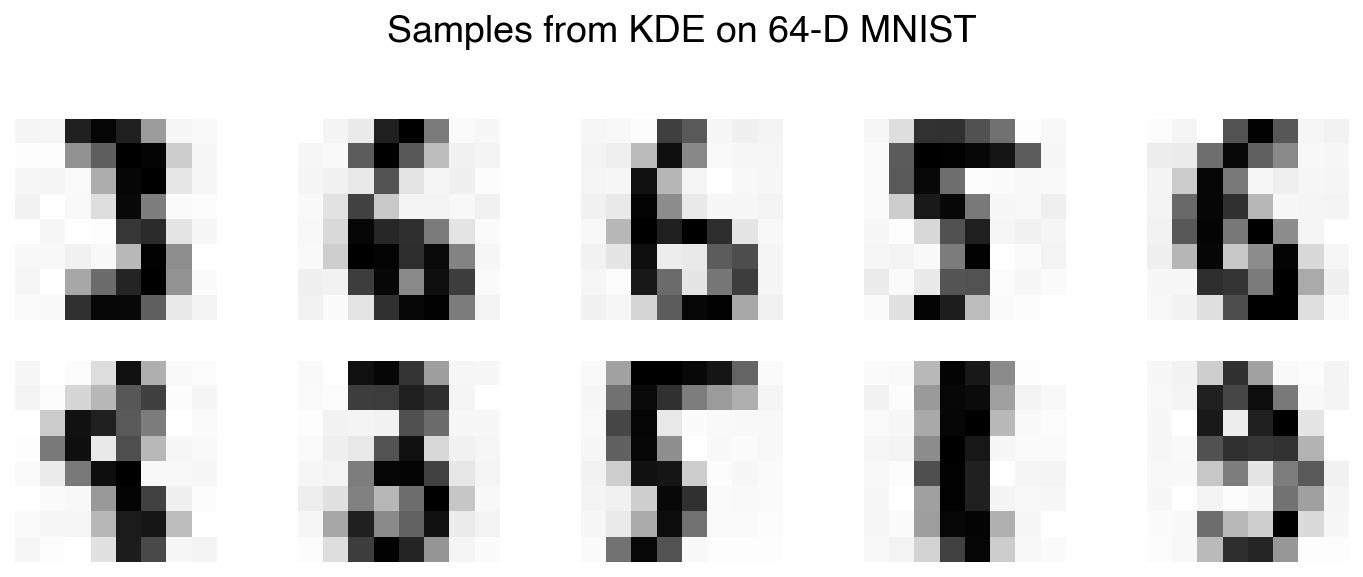

In [28]:
kde_images = KernelDensity(bandwidth=0.25, kernel='gaussian')
kde_images.fit(X_mnist)

# KernelDensity.sample() also reseeds from random_state each call —
# draw all 10 at once to get distinct images
kde_samples = kde_images.sample(n_samples=10)  # shape (10, 64)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, sample in zip(axes.ravel(), kde_samples):
    show_image(sample, ax=ax)
fig.suptitle('Samples from KDE on 64-D MNIST');

The samples are recognizable as handwritten digits generated entirely by the computer.
The bandwidth was chosen manually here; in practice, cross-validation or leave-one-out
likelihood maximization can be used to tune it systematically.

This idea — learning a smooth probability distribution over raw pixel space and sampling
from it — underlies more sophisticated models such as Variational Autoencoders (VAEs) and
Generative Adversarial Networks (GANs), which replace Gaussian kernels with deep neural
networks.

## Bayesian Classification with Kernel Density Estimation

So far we have used generative models purely for data synthesis and exploration. We can also
use them to build **probabilistic classifiers** via Bayes' theorem:

$$P(y = c \mid \mathbf{x}) \propto P(\mathbf{x} \mid y = c) \cdot P(y = c)$$

Read left to right, this says: the probability that a point $\mathbf{x}$ belongs to class $c$
(the **posterior**) is proportional to how likely that point is under class $c$'s own density
(the **class-conditional likelihood**) times how common class $c$ is to begin with (the
**prior**). The key idea is that we never model the classes jointly — we fit a *separate*
generative model to each class, then ask which class makes the observed point most plausible.
Each piece comes from something we already know how to compute: $P(\mathbf{x} \mid y = c)$ is
estimated by fitting a generative model (a KDE or GMM) to only the class-$c$ training points,
and $P(y = c)$ is just the fraction of training points in class $c$. The symbol $\propto$
("proportional to") lets us drop the denominator $P(\mathbf{x})$ from the full theorem, because
it is the same for every class and so does not change which class wins. To classify a new
point we evaluate the right-hand side for every class and pick the largest.

This recipe should look familiar: the **Naive Bayes** classifier from
[Alternate Classification Models](../3-classification/Topic3.3-Alternate_Classification_Models)
is exactly this construction, with the simplifying assumption that the features are
independent so each class density factorizes into a separate 1-D Gaussian per feature. That
assumption is often too restrictive for real data. The approach below instead fits a **full
multivariate KDE** to each class, capturing all feature correlations — hence the name
"not-so-naive Bayes."

In [29]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(
    X_mnist, y_mnist, test_size=0.3, random_state=1)

In [30]:
def kde_bayes_predict(X_train, X_test, y_train, bandwidth=10):
    """Classify X_test using per-class KDE generative models and Bayes' theorem."""
    classes = np.unique(y_train)
    log_posteriors = np.zeros((len(X_test), len(classes)))
    for i, c in enumerate(classes):
        X_c = X_train[y_train == c]
        prior = np.log(len(X_c) / len(X_train))
        kde_c = KernelDensity(bandwidth=bandwidth,
                              kernel='gaussian').fit(X_c)
        log_posteriors[:, i] = kde_c.score_samples(X_test) + prior
    return classes[np.argmax(log_posteriors, axis=1)]

In [31]:
y_pred = kde_bayes_predict(X_train, X_test, y_train, bandwidth=10)
print(f"KDE Bayes accuracy: {accuracy_score(y_test, y_pred):.4f}")

KDE Bayes accuracy: 0.9907


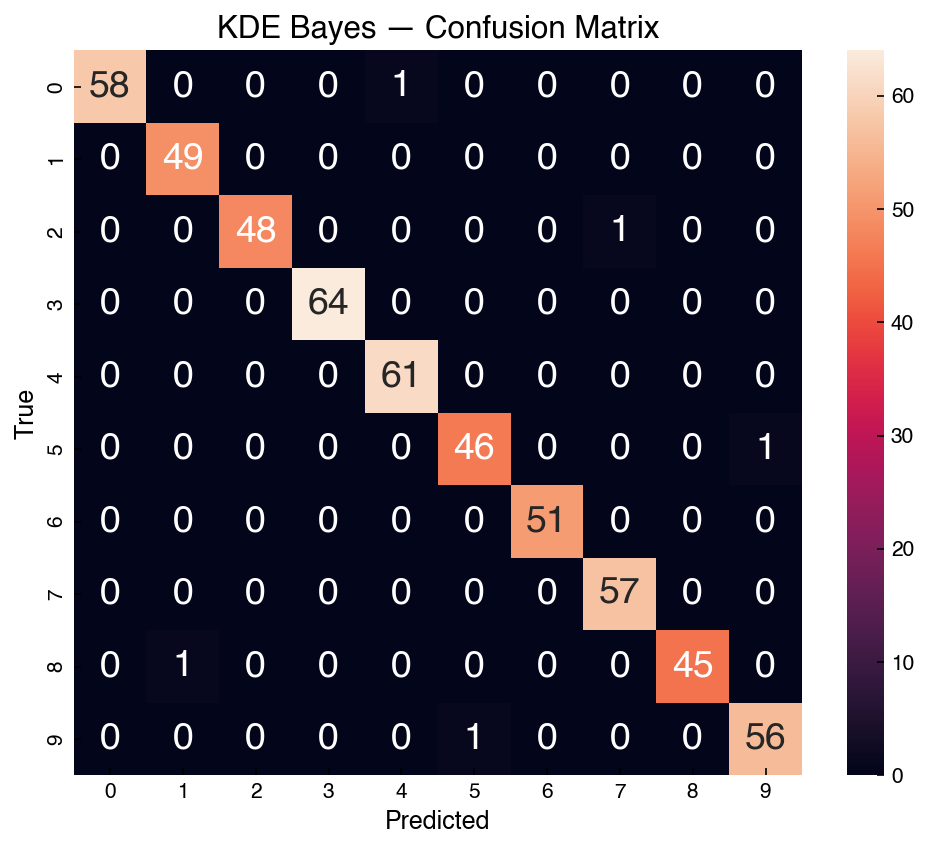

In [32]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pd.DataFrame(cm, index=range(10), columns=range(10)),
            annot=True, fmt='d', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('KDE Bayes — Confusion Matrix');

The KDE-based classifier achieves approximately 99% accuracy on the test set. For
comparison, standard Gaussian Naive Bayes — which assumes independent features — achieves
only about 83%:

In [33]:
nb = GaussianNB().fit(X_train, y_train)
print(f"Gaussian Naive Bayes accuracy: {nb.score(X_test, y_test):.4f}")

Gaussian Naive Bayes accuracy: 0.8315


The 16-percentage-point gap illustrates how much information is lost by ignoring feature
correlations. Adjacent pixels in a digit image are strongly correlated, and naive Bayes
discards all of that structure. By fitting a full multivariate KDE to each class, the
not-so-naive classifier captures these correlations and achieves near-perfect accuracy.

:::{exercise}
:label: ex-eda-kde-bw-cls

Re-run `kde_bayes_predict` with three different bandwidth values: 1, 10, and 50. Print the
test-set accuracy for each. Which bandwidth gives the best performance, and why do you think
very small or very large bandwidths hurt accuracy?
:::

## Generative Model for the Full Dow Dataset

The examples above used only 1–2 features of the Dow dataset. A truly useful generative
model must capture all 40 process variables simultaneously. The strategy is the same as for
MNIST: standardize the data (process variables have different units and ranges), reduce with
PCA, fit a GMM with BIC selection, then invert both transforms to produce full-dimensional
synthetic process records.

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_dow_scaled = scaler.fit_transform(X_dow)

pca_dow = PCA(n_components=0.95, random_state=0)
X_dow_k = pca_dow.fit_transform(X_dow_scaled)
print(f"PCA components retained: {pca_dow.n_components_} / {X_dow.shape[1]}")
print(f"Variance retained: {pca_dow.explained_variance_ratio_.sum():.1%}")

PCA components retained: 12 / 40
Variance retained: 95.5%


Optimal GMM components: 85


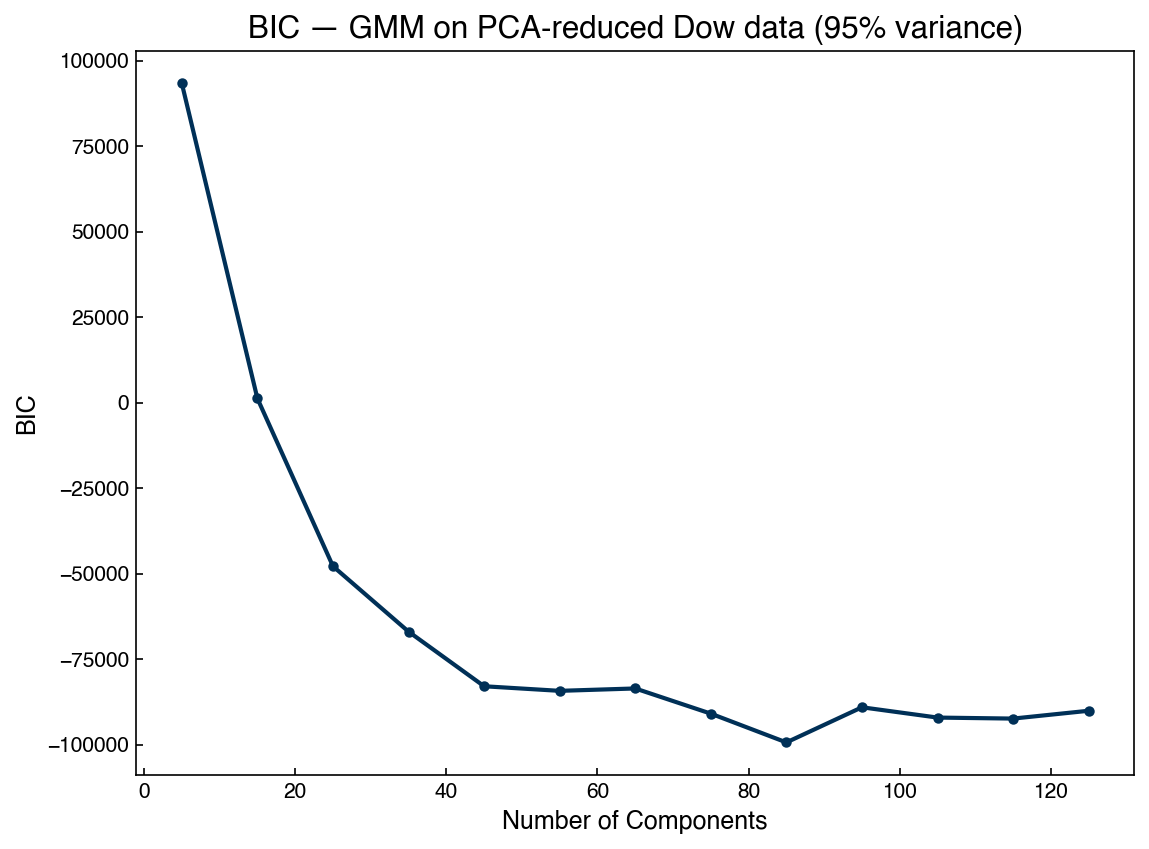

In [35]:
n_range_dow = np.arange(5, 131, 10)
bics_dow, models_dow = [], []
for n in n_range_dow:
    g = GaussianMixture(n, covariance_type='full',
                        random_state=0).fit(X_dow_k)
    bics_dow.append(g.bic(X_dow_k))
    models_dow.append(g)

best_dow_idx = np.argmin(bics_dow)
best_dow_gmm = models_dow[best_dow_idx]
print(f"Optimal GMM components: {n_range_dow[best_dow_idx]}")

fig, ax = plt.subplots()
ax.plot(n_range_dow, bics_dow, marker='o', markersize=4)
ax.set_xlabel('Number of Components')
ax.set_ylabel('BIC')
ax.set_title('BIC — GMM on PCA-reduced Dow data (95% variance)');

Unlike the tidy 2-D example earlier in this chapter, the BIC here descends steeply and then
flattens into a broad, shallow basin: the optimum sits at *several dozen* components, and its
exact location wanders with the random initialization. This is the same lesson as in
[Clustering](Topic5.3-Clustering) — real process data is not a handful of clean Gaussians, so
BIC keeps rewarding extra components that help the mixture approximate a continuous density.
Note that this is why we extended the search well beyond the ~20 components used for the 2-D
example: stopping too early would have put the "optimum" at the edge of the range rather than
at a true minimum. For *generation*, a large number of components is perfectly fine — even
desirable — because the goal is to reproduce the data distribution, not to identify a few
meaningful clusters.

In [36]:
X_synth_k, _ = best_dow_gmm.sample(len(X_dow))
X_synth = scaler.inverse_transform(pca_dow.inverse_transform(X_synth_k))
print(f"Synthetic data shape: {X_synth.shape}")

Synthetic data shape: (10297, 40)


We compare the marginal distributions of four representative process features:

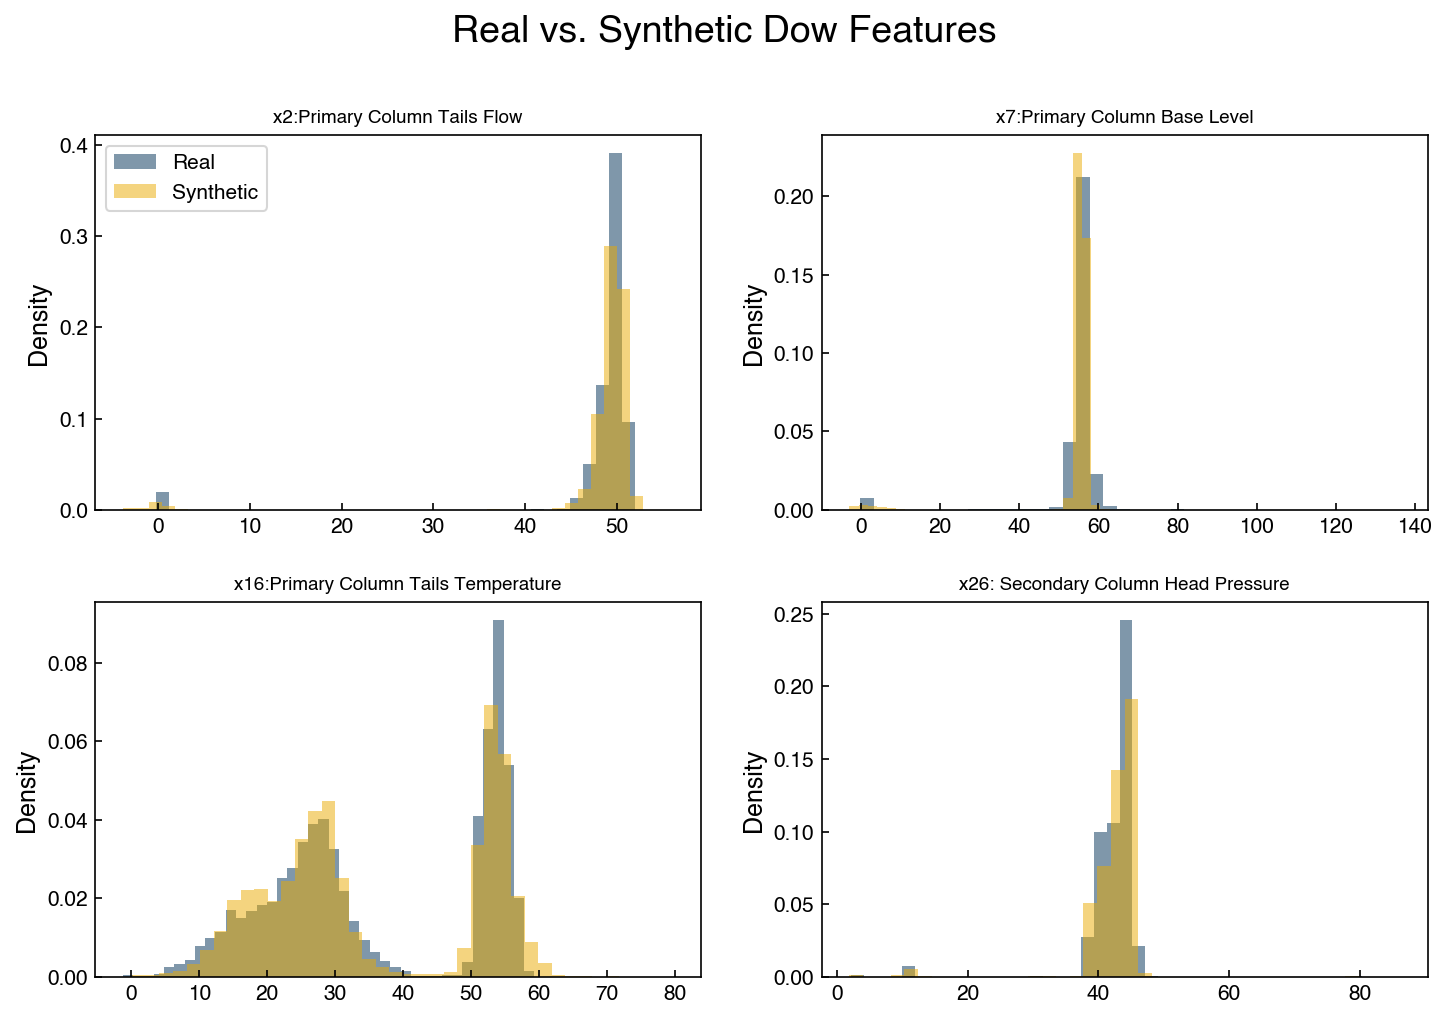

In [37]:
feature_cols = [1, 6, 15, 25]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), feature_cols):
    ax.hist(X_dow[:, col], density=True, alpha=0.5, bins=40, label='Real')
    ax.hist(X_synth[:, col], density=True, alpha=0.5, bins=40, label='Synthetic')
    ax.set_title(df.columns[col + 1], fontsize=9)
    ax.set_ylabel('Density')
axes[0, 0].legend()
fig.suptitle('Real vs. Synthetic Dow Features')
plt.tight_layout();

The marginal distributions of the synthetic data closely mirror the real data. The PCA step
is critical here: fitting a GMM directly in 40-D with a full covariance matrix would require
estimating $40 \times 41 / 2 = 820$ parameters per component — orders of magnitude more than
after PCA reduction.

:::{exercise}
:label: ex-eda-gmm-dow-full

Re-run the full Dow generative pipeline with `n_components=0.80` (retaining 80% of the
variance instead of 95%). How many PCA components are used? Does the synthetic data still
match the real feature distributions reasonably well? Print the number of PCA components and
overlay the histograms for the same four features.
:::

## Anomaly Detection with Density Models

In Topic 5.1 we identified unusual data points visually using scatter plots and univariate
histograms. Generative models offer a quantitative, multivariate alternative: assign every
data point a log-probability score under the fitted density and flag points in the lowest
percentile as statistically anomalous. A point with very low probability is one that the
model has rarely seen — it lives in a low-density region of feature space.

We reuse the Dow GMM from the previous section. The `score_samples` method returns the
per-sample log-probability $\ln P(\mathbf{x})$ in the reduced PCA space:

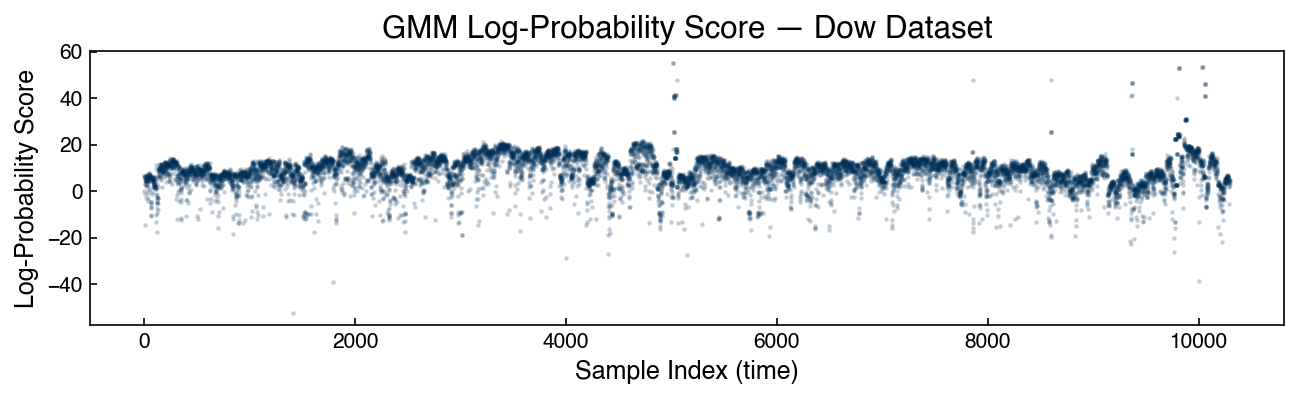

In [38]:
log_scores = best_dow_gmm.score_samples(X_dow_k)

fig, ax = plt.subplots(figsize=(9, 3))
ax.scatter(range(len(log_scores)), log_scores, alpha=0.15, s=2, c=clrs[0])
ax.set_xlabel('Sample Index (time)')
ax.set_ylabel('Log-Probability Score')
ax.set_title('GMM Log-Probability Score — Dow Dataset');

We flag the bottom 1% of scores as anomalous:

Anomalous points flagged: 103 / 10297


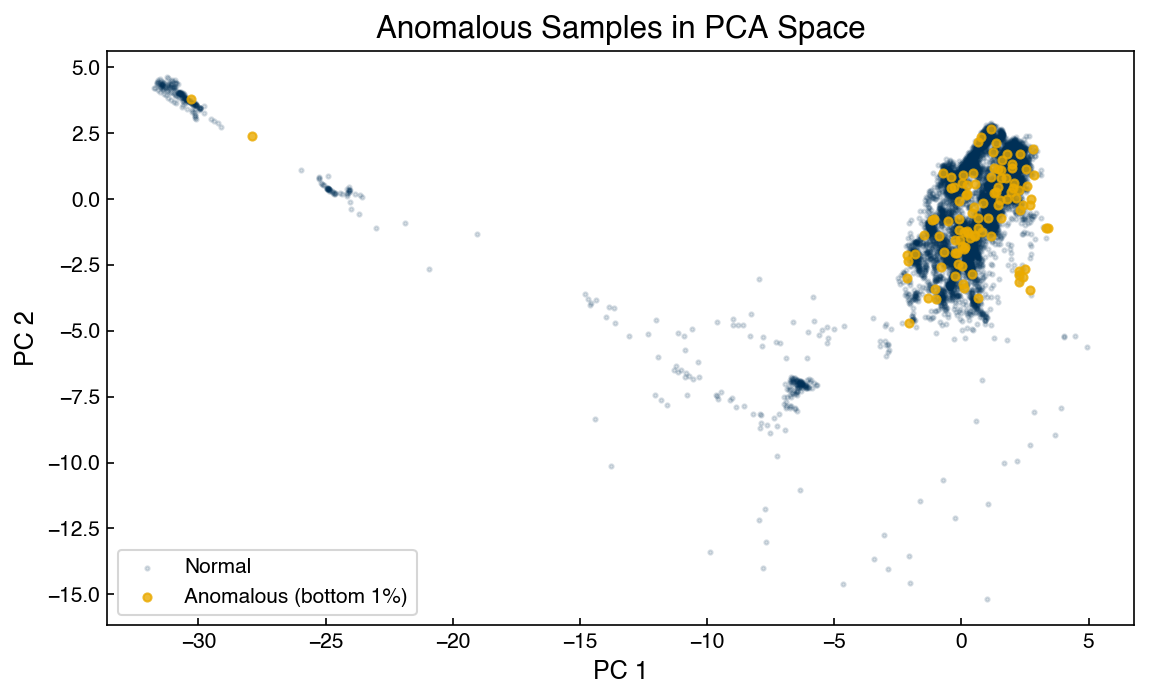

In [39]:
threshold = np.percentile(log_scores, 1)
anomaly_mask = log_scores < threshold
print(f"Anomalous points flagged: {anomaly_mask.sum()} / {len(X_dow)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_dow_k[~anomaly_mask, 0], X_dow_k[~anomaly_mask, 1],
           alpha=0.15, s=4, c=clrs[0], label='Normal')
ax.scatter(X_dow_k[anomaly_mask, 0], X_dow_k[anomaly_mask, 1],
           alpha=0.8, s=15, c=clrs[1], label='Anomalous (bottom 1%)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Anomalous Samples in PCA Space')
ax.legend();

The flagged points cluster at the edges of the data cloud in PCA space — exactly the sparse,
low-density regions where we would expect unusual operating conditions. We can also check
whether these anomalous time steps correspond to elevated product impurity:

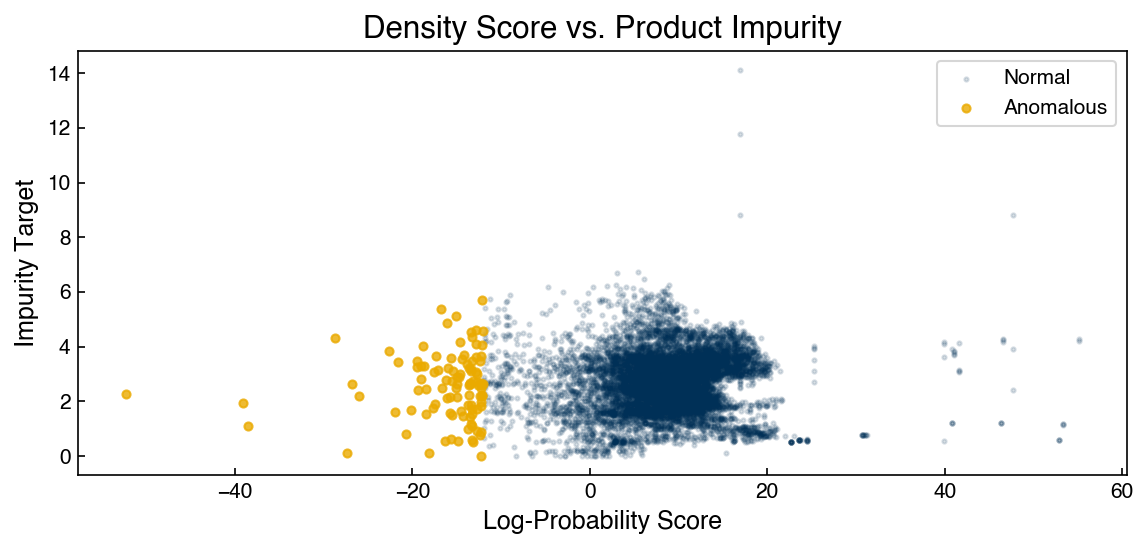

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(log_scores[~anomaly_mask], y_dow[~anomaly_mask],
           alpha=0.15, s=4, c=clrs[0], label='Normal')
ax.scatter(log_scores[anomaly_mask], y_dow[anomaly_mask],
           alpha=0.8, s=15, c=clrs[1], label='Anomalous')
ax.set_xlabel('Log-Probability Score')
ax.set_ylabel('Impurity Target')
ax.set_title('Density Score vs. Product Impurity')
ax.legend();

:::{note}
A weak but visible trend is typically present: points flagged as anomalous by the density
model tend to have higher product impurity on average. This confirms that low-probability
process states are industrially meaningful, not just statistical artifacts. The strength of
the association will depend on how well the training data captures normal operation.
:::

:::{exercise}
:label: ex-eda-anomaly-score

Re-run the anomaly detection using the full-dimensional KDE model (`kde_dow` applied to
`X_dow_k`). Compare the anomalous points flagged by the KDE to those flagged by the GMM:
how many overlap? Which method flags anomalies in a wider region of PCA space? Use a 2%
percentile threshold for both.
:::

## Summary

- **Generative models** estimate $P(\mathbf{x})$, the probability distribution of the data
  itself, without requiring output labels.
- The **normal distribution** is the simplest generative model; fitting it to a feature
  requires only computing the sample mean and standard deviation.
- **Gaussian Mixture Models (GMMs)** extend the normal distribution to multi-modal
  distributions by fitting a weighted sum of Gaussians using the EM algorithm.
- The **Bayesian Information Criterion (BIC)** balances goodness-of-fit against model
  complexity and provides a principled way to select the number of GMM components.
- In high dimensions, combining **PCA + GMM** reduces the parameter count while retaining
  most generative fidelity; samples from the GMM are projected back via the inverse PCA
  transform.
- **Kernel Density Estimation (KDE)** places a Gaussian kernel on every data point, yielding
  a fully non-parametric density that makes no assumptions about the number of clusters.
- KDE combined with Bayes' theorem produces a **probabilistic classifier** that captures full
  multivariate structure per class, substantially outperforming naive Bayes on correlated
  data.
- The optimal KDE **bandwidth** can be selected via cross-validation by maximizing held-out
  log-likelihood, avoiding manual tuning.
- A full-dimensional generative model for process data is built by standardizing features,
  compressing with PCA, fitting a BIC-optimal GMM, and inverting both transforms to produce
  realistic synthetic process records.
- **Anomaly detection** with density models assigns each sample a log-probability score;
  points in the lowest percentile are flagged as operating in statistically rare regions,
  providing a quantitative complement to visual outlier inspection.

## Additional Reading

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*
  (2nd ed.). Springer. Chapter 6 (Kernel Methods) and Chapter 8 (Model Inference and
  Averaging).
- VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly. Sections on Gaussian
  Mixture Models and Kernel Density Estimation in Chapter 5.
- scikit-learn documentation: [Gaussian Mixture Models](https://scikit-learn.org/stable/modules/mixture.html)
  and [Density Estimation](https://scikit-learn.org/stable/modules/density.html).